# 기업 신용평가 합성 데이터 - 탐색적 데이터 분석 (EDA)

## 목표
1. 데이터 품질 및 구조 이해
2. 업종별/신용등급별 재무 특성 파악
3. 부도 기업 패턴 분석
4. 프로젝트 방향성 결정을 위한 인사이트 도출
5. 가명식별자 없는 문제 - 대안 탐색

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. 데이터 로드 및 기본 정보

In [5]:
# CSV 데이터 로드
df = pd.read_csv('/Users/kje/coding/project/fintech-cb-pipeline/data/raw/기업신용평가정보_합성데이터.csv', encoding='cp949')

print(f"데이터 shape: {df.shape}")
print(f"총 행 수: {len(df):,}")
print(f"총 컬럼 수: {len(df.columns)}")
print(f"\n메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

데이터 shape: (600000, 159)
총 행 수: 600,000
총 컬럼 수: 159

메모리 사용량: 757.60 MB


In [6]:
# 데이터 타입 확인
df.dtypes.value_counts()

int64      97
float64    61
object      1
Name: count, dtype: int64

In [6]:
# 기본 통계량
df.describe()

,기준년월,외감구분,설립일자,종업원수,주소지시군구,상장일자,상장폐지일자,유동자산,비유동자산,당좌자산,...,신용도판단정보공공정보건수(CIS)(미해제),신용도판단정보공공정보건수(관련인제외)(CIS)(당월유지)(해제포함),"공공정보(국세,지방세,관세체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(5년내발생)","신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)","신용도판단정보공공정보최근해제일자로부터경과일수(CIS)(해제,삭제)",기업신용평가등급(구간화),모형개발용Performance(향후1년내부도여부)
count,6.000000e+05,600000.000000,6.000000e+05,600000.000000,550992.000000,2.205500e+04,4.040000e+02,6.000000e+05,6.000000e+05,6.000000e+05,...,600000.000000,600000.00000,600000.000000,600000.000000,600000.000000,600000.000000,6.000000e+05,6.000000e+05,600000.000000,600000.000000
mean,2.021648e+07,1.630425,2.006622e+07,94.697897,32924.609689,2.003879e+07,2.013151e+07,3.869108e+07,6.715065e+07,2.944310e+07,...,0.009487,0.00946,0.007827,0.007737,0.009385,0.009167,9.559600e+08,9.559600e+08,4.676333,0.014962
std,4.637682e+03,0.482690,1.167924e+05,839.073471,13678.668711,1.276706e+05,8.007689e+04,8.439673e+08,2.093429e+09,6.834555e+08,...,0.159269,0.16048,0.148162,0.146732,0.160157,0.155594,2.051840e+08,2.051840e+08,2.083815,0.121400
min,2.021080e+07,1.000000,1.915093e+07,1.000000,11110.000000,1.955092e+07,2.002091e+07,-9.087020e+05,-1.885779e+08,-9.087020e+05,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2.021108e+07,1.000000,2.000121e+07,4.000000,26260.000000,1.996091e+07,2.005033e+07,7.237608e+05,2.785395e+05,5.035488e+05,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+09,1.000000e+09,3.000000,0.000000
50%,2.022015e+07,2.000000,2.010052e+07,14.000000,41171.000000,2.005080e+07,2.010567e+07,2.493290e+06,1.943666e+06,1.795284e+06,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+09,1.000000e+09,5.000000,0.000000
75%,2.022043e+07,2.000000,2.015111e+07,46.000000,44131.000000,2.014121e+07,2.022031e+07,1.065772e+07,1.059236e+07,7.375427e+06,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+09,1.000000e+09,6.000000,0.000000
max,2.022070e+07,2.000000,2.021083e+07,125782.000000,51830.000000,2.023083e+07,2.023083e+07,1.526740e+11,3.596010e+11,1.207270e+11,...,33.000000,33.00000,33.000000,33.000000,33.000000,33.000000,1.000000e+09,1.000000e+09,10.000000,1.000000


## 2. 시간 범위 및 관측 주기

In [7]:
# 기준년월 분석
df['기준년월'] = df['기준년월'].astype(str)
df['기준년월_date'] = pd.to_datetime(df['기준년월'], format='%Y%m%d')

print(f"기간: {df['기준년월'].min()} ~ {df['기준년월'].max()}")
print(f"관측 월수: {df['기준년월'].nunique()}")
print(f"\n월별 데이터 수:")
print(df['기준년월'].value_counts().sort_index())

기간: 20210801 ~ 20220701
관측 월수: 12

월별 데이터 수:
기준년월
20210801    50000
20210901    50000
20211001    50000
20211101    50000
20211201    50000
20220101    50000
20220201    50000
20220301    50000
20220401    50000
20220501    50000
20220601    50000
20220701    50000
Name: count, dtype: int64


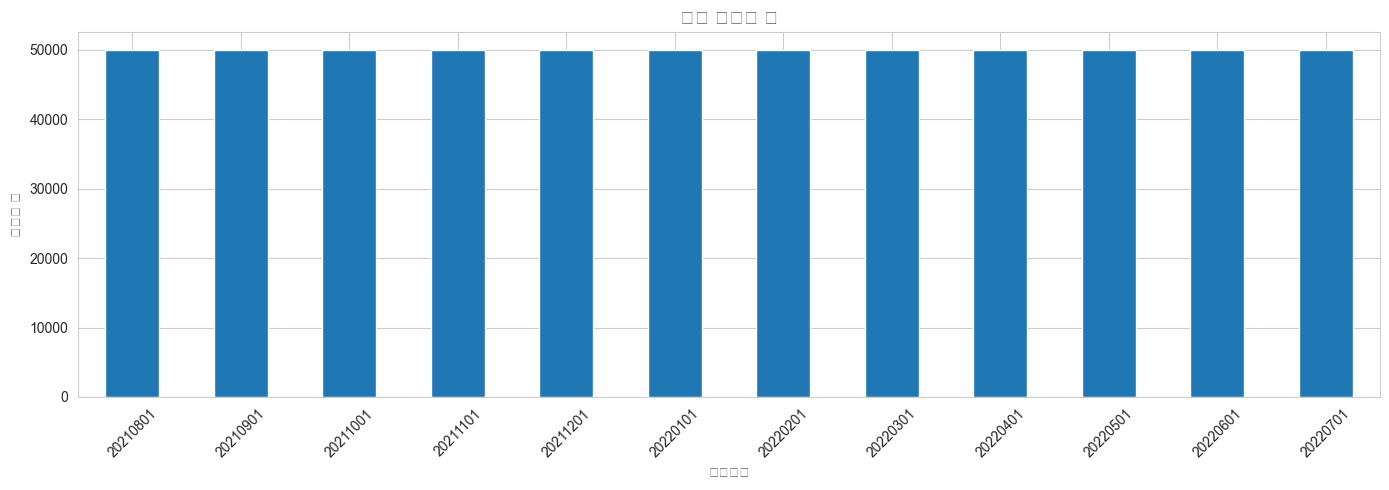

In [8]:
# 월별 데이터 분포 시각화
plt.figure(figsize=(14, 5))
df['기준년월'].value_counts().sort_index().plot(kind='bar')
plt.title('월별 데이터 수', fontsize=14, fontweight='bold')
plt.xlabel('기준년월')
plt.ylabel('데이터 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. 가명식별자 문제 - 대안 탐색

항목설명에는 가명식별자가 있다고 되어 있지만, 실제 데이터에는 없습니다.  
개별 기업을 시계열로 추적할 수 없는 문제가 있습니다.

**대안 1**: 유사 식별자 생성 시도  
**대안 2**: 횡단면 분석으로 전환 (집단 통계)

In [8]:
# 가명식별자 대안 - 조합으로 기업 구분 시도
# 설립일자 + 업종 + 주소지 + 종업원수 조합
df['pseudo_id'] = (
    df['설립일자'].astype(str) + '_' + 
    df['업종(중분류)'].astype(str) + '_' + 
    df['주소지시군구'].astype(str) + '_' + 
    df['종업원수'].astype(str)
)

print("=== 유사 식별자 생성 결과 ===")
print(f"총 행 수: {len(df):,}")
print(f"고유 pseudo_id 수: {df['pseudo_id'].nunique():,}")
print(f"월 수: {df['기준년월'].nunique()}")
print(f"\n예상 기업 수 (총 행수 / 월수): {len(df) // df['기준년월'].nunique():,}")
print(f"실제 고유 조합 수: {df['pseudo_id'].nunique():,}")

# 중복도 확인
id_counts = df.groupby('pseudo_id').size()
print(f"\n=== 중복도 분석 ===")
print(f"1회만 나타나는 조합: {(id_counts == 1).sum():,}")
print(f"2~12회 나타나는 조합: {((id_counts >= 2) & (id_counts <= 12)).sum():,}")
print(f"13회 이상 나타나는 조합: {(id_counts > 12).sum():,}")

=== 유사 식별자 생성 결과 ===
총 행 수: 600,000
고유 pseudo_id 수: 595,157
월 수: 12

예상 기업 수 (총 행수 / 월수): 50,000
실제 고유 조합 수: 595,157

=== 중복도 분석 ===
1회만 나타나는 조합: 590,438
2~12회 나타나는 조합: 4,719
13회 이상 나타나는 조합: 0


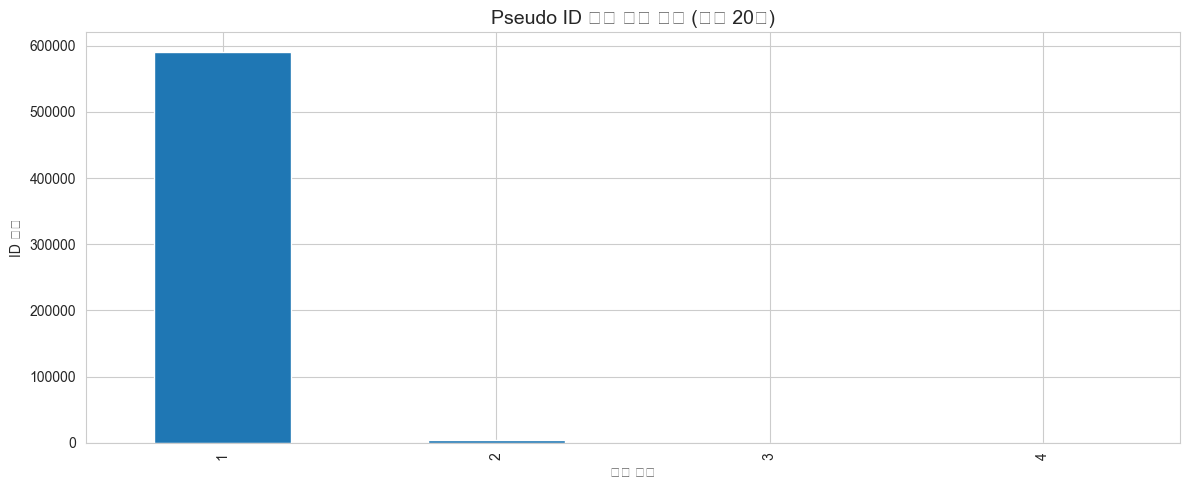


⚠️ 결론: pseudo_id의 유효성 판단
- 12회 출현하는 ID가 대부분이면 → 시계열 추적 가능
- 1회만 나타나는 ID가 많으면 → 식별자로 부적합, 횡단면 분석 필요


In [9]:
# pseudo_id 분포 시각화
plt.figure(figsize=(12, 5))
id_counts.value_counts().sort_index().head(20).plot(kind='bar')
plt.title('Pseudo ID 출현 횟수 분포 (상위 20개)', fontsize=14)
plt.xlabel('출현 횟수')
plt.ylabel('ID 개수')
plt.tight_layout()
plt.show()

print("\n⚠️ 결론: pseudo_id의 유효성 판단")
print("- 12회 출현하는 ID가 대부분이면 → 시계열 추적 가능")
print("- 1회만 나타나는 ID가 많으면 → 식별자로 부적합, 횡단면 분석 필요")

## 4. 업종 분석

In [10]:
# 업종 분포
industry_counts = df['업종(중분류)'].value_counts()
print(f"총 업종 수: {len(industry_counts)}")
print(f"\n상위 20개 업종:")
print(industry_counts.head(20))

총 업종 수: 74

상위 20개 업종:
업종(중분류)
G46    81292
G47    44520
F42    42249
C29    33919
F41    32229
L68    30282
C10    21995
C25    21844
J58    17988
C26    16583
C20    16020
C30    15906
C28    14627
C22    13757
M71    12518
N75    12097
M72    11210
C24     9379
C23     9109
H52     8253
Name: count, dtype: int64


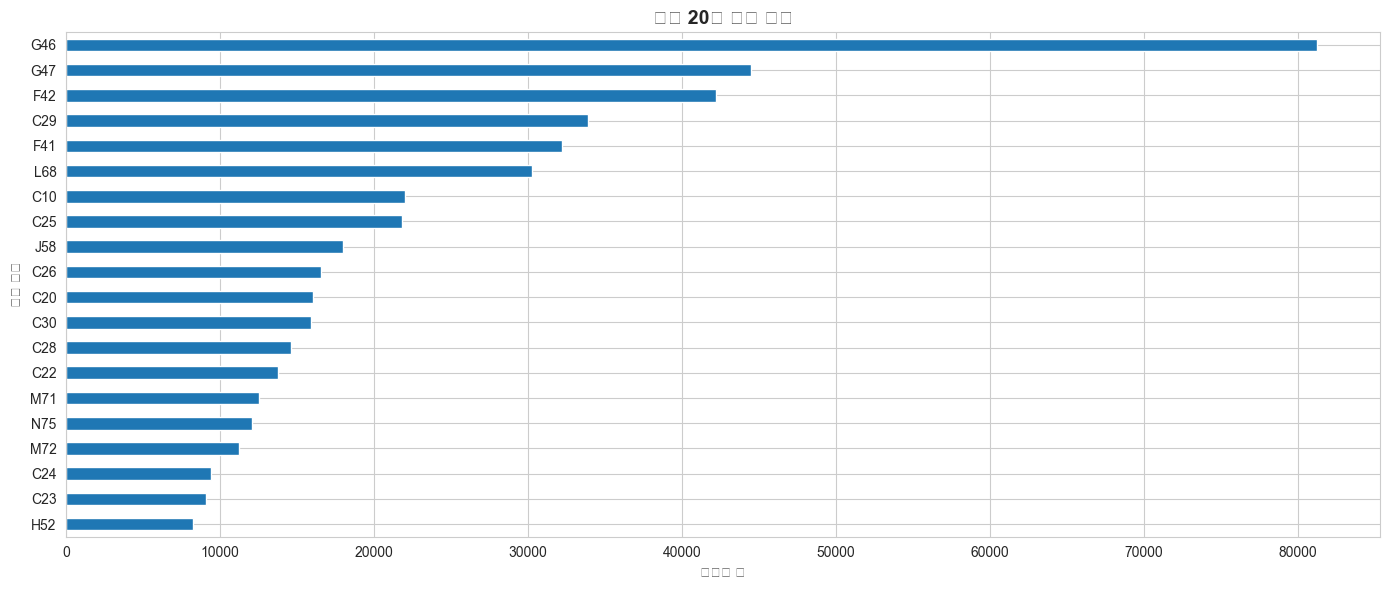

In [11]:
# 업종별 분포 시각화
plt.figure(figsize=(14, 6))
industry_counts.head(20).plot(kind='barh')
plt.title('상위 20개 업종 분포', fontsize=14, fontweight='bold')
plt.xlabel('데이터 수')
plt.ylabel('업종 코드')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. 외감 여부 및 상장 여부

In [12]:
# 외감 여부
print("=== 외감 여부 ===")
print(df['외감구분'].value_counts())
print(f"\n외감 비율: {(df['외감구분'] == 1).sum() / len(df) * 100:.1f}%")
print(f"비외감 비율: {(df['외감구분'] == 2).sum() / len(df) * 100:.1f}%")

=== 외감 여부 ===
외감구분
2    378255
1    221745
Name: count, dtype: int64

외감 비율: 37.0%
비외감 비율: 63.0%


In [13]:
# 상장 여부
df['상장여부'] = df['상장일자'].notna()
print("\n=== 상장 여부 ===")
print(f"상장 기업: {df['상장여부'].sum():,} ({df['상장여부'].sum() / len(df) * 100:.1f}%)")
print(f"비상장 기업: {(~df['상장여부']).sum():,} ({(~df['상장여부']).sum() / len(df) * 100:.1f}%)")


=== 상장 여부 ===
상장 기업: 22,055 (3.7%)
비상장 기업: 577,945 (96.3%)


In [14]:
# 외감 vs 상장 교차 분석
pd.crosstab(df['외감구분'], df['상장여부'], margins=True)

상장여부,False,True,All
외감구분,,,
1,199690,22055,221745
2,378255,0,378255
All,577945,22055,600000


## 6. 신용등급 분석

=== 신용등급 분포 ===
기업신용평가등급(구간화)
0        478
1      43419
2      52304
3      81813
4     112135
5      98296
6      87847
7      71714
8      33623
9       9460
10      8911
Name: count, dtype: int64


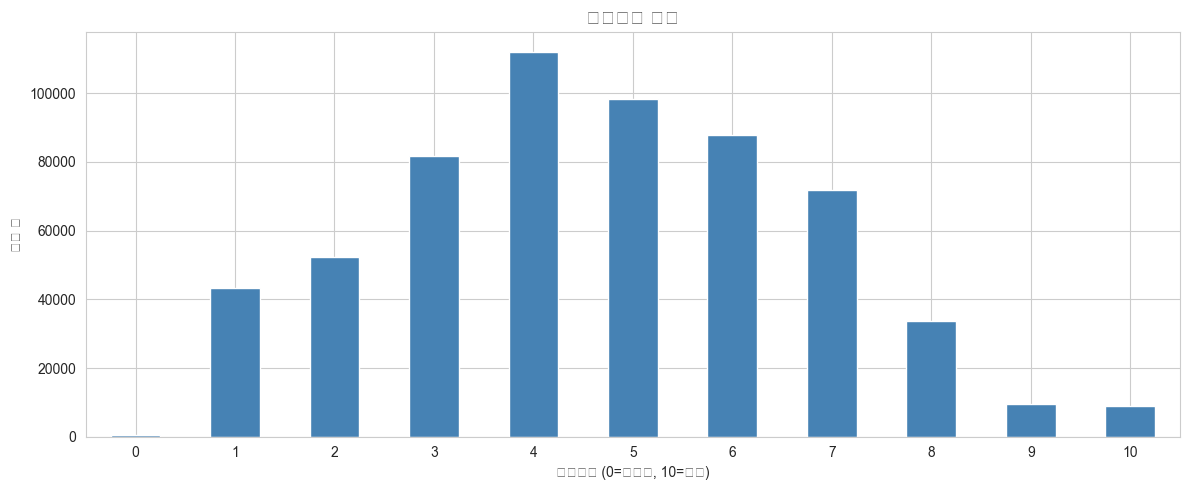

In [15]:
# 신용등급 분포
grade_counts = df['기업신용평가등급(구간화)'].value_counts().sort_index()
print("=== 신용등급 분포 ===")
print(grade_counts)

plt.figure(figsize=(12, 5))
grade_counts.plot(kind='bar', color='steelblue')
plt.title('신용등급 분포', fontsize=14, fontweight='bold')
plt.xlabel('신용등급 (0=최우수, 10=최하)')
plt.ylabel('기업 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

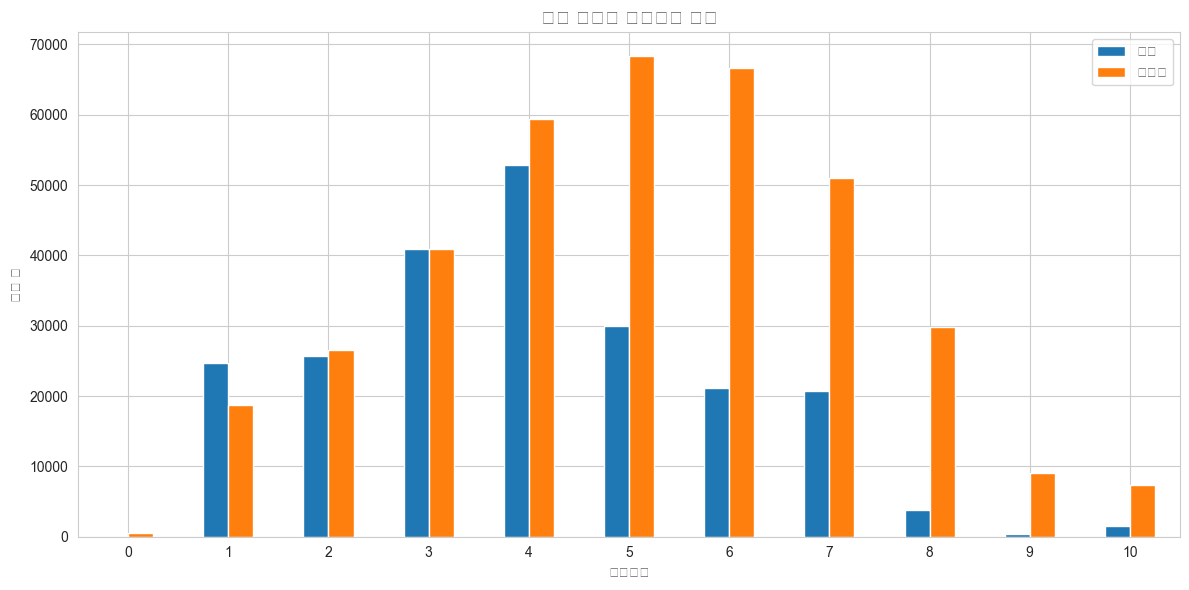

In [16]:
# 외감 여부별 신용등급 분포
plt.figure(figsize=(14, 6))
df_pivot = df.groupby(['기업신용평가등급(구간화)', '외감구분']).size().unstack(fill_value=0)
df_pivot.plot(kind='bar', stacked=False)
plt.title('외감 여부별 신용등급 분포', fontsize=14, fontweight='bold')
plt.xlabel('신용등급')
plt.ylabel('기업 수')
plt.legend(['외감', '비외감'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. 부도 분석 (Performance)

=== 부도 여부 ===
모형개발용Performance(향후1년내부도여부)
0    591023
1      8977
Name: count, dtype: int64

부도율: 1.50%


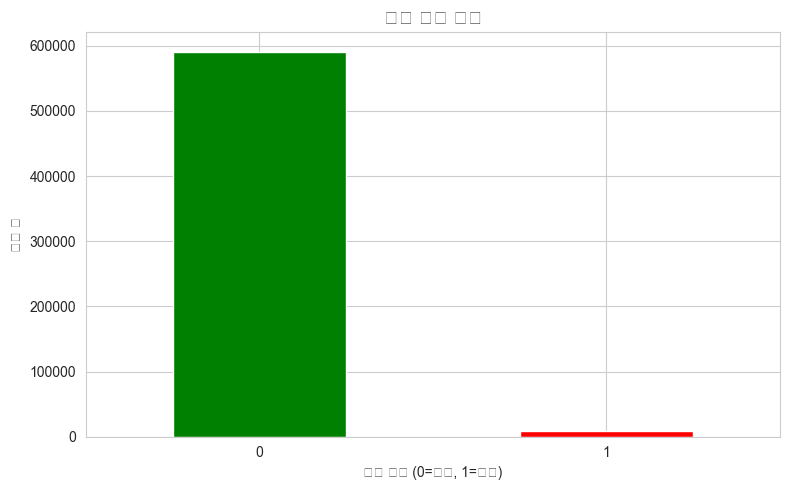

In [18]:
# 부도 비율
default_rate = df['모형개발용Performance(향후1년내부도여부)'].value_counts()
print("=== 부도 여부 ===")
print(default_rate)
print(f"\n부도율: {default_rate[1] / len(df) * 100:.2f}%")

plt.figure(figsize=(8, 5))
default_rate.plot(kind='bar', color=['green', 'red'])
plt.title('부도 여부 분포', fontsize=14, fontweight='bold')
plt.xlabel('부도 여부 (0=정상, 1=부도)')
plt.ylabel('기업 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== 신용등급별 부도율 ===
                sum   count  부도율(%)
기업신용평가등급(구간화)                      
0                 0     478    0.00
1                50   43419    0.12
2                14   52304    0.03
3               187   81813    0.23
4               298  112135    0.27
5               756   98296    0.77
6              1392   87847    1.58
7              1900   71714    2.65
8              1822   33623    5.42
9              1322    9460   13.97
10             1236    8911   13.87


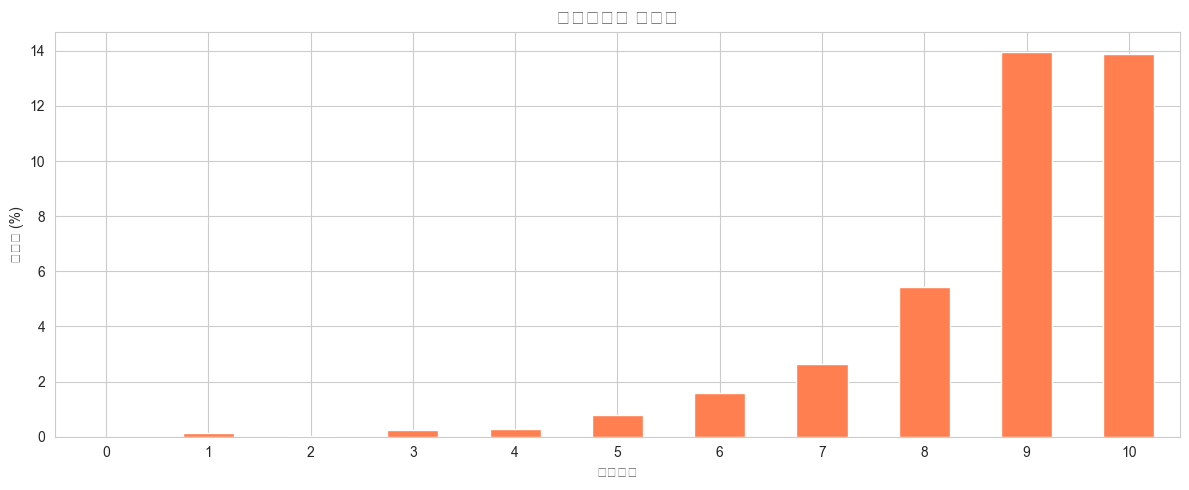

In [19]:
# 신용등급별 부도율
default_by_grade = df.groupby('기업신용평가등급(구간화)')['모형개발용Performance(향후1년내부도여부)'].agg(['sum', 'count'])
default_by_grade['부도율(%)'] = (default_by_grade['sum'] / default_by_grade['count'] * 100).round(2)
print("\n=== 신용등급별 부도율 ===")
print(default_by_grade)

plt.figure(figsize=(12, 5))
default_by_grade['부도율(%)'].plot(kind='bar', color='coral')
plt.title('신용등급별 부도율', fontsize=14, fontweight='bold')
plt.xlabel('신용등급')
plt.ylabel('부도율 (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. 재무 지표 분석

In [20]:
# 주요 재무 지표 선정
financial_cols = [
    '유동자산', '비유동자산', '자기자본(자본총계)', '부채총계',
    '매출액', '영업이익', '당기순이익', '총자산'
]

# 재무비율 컬럼
ratio_cols = [col for col in df.columns if '재무비율' in col]
print(f"재무비율 컬럼 수: {len(ratio_cols)}")
print("\n재무비율 컬럼 목록:")
for col in ratio_cols:
    print(f"  - {col}")

재무비율 컬럼 수: 18

재무비율 컬럼 목록:
  - 재무비율_총자산증가율
  - 재무비율_부채비율
  - 재무비율_자기자본비율
  - 재무비율_유동비율
  - 재무비율_차입금의존도
  - 재무비율_매출액증가율
  - 재무비율_영업이익율
  - 재무비율_당기순이익율
  - 재무비율_매출원가율
  - 재무비율_판관비율
  - 재무비율_자기자본이익률(ROE)
  - 재무비율_매출채권회전율
  - 재무비율_재고자산회전율
  - 재무비율_매입채무회전율
  - 재무비율_총자산회전율
  - 재무비율_총자산순이익률
  - 재무비율_유동자산증가율
  - 재무비율_유형자산증가율


In [21]:
# 주요 재무 지표 기본 통계
df[financial_cols].describe()

KeyError: "['자기자본(자본총계)', '영업이익', '총자산'] not in index"

In [22]:
# 재무비율 기본 통계
key_ratios = [
    '재무비율_부채비율', '재무비율_자기자본비율', '재무비율_유동비율',
    '재무비율_영업이익율', '재무비율_당기순이익율', '재무비율_총자산증가율'
]

df[key_ratios].describe()

,재무비율_부채비율,재무비율_자기자본비율,재무비율_유동비율,재무비율_영업이익율,재무비율_당기순이익율,재무비율_총자산증가율
count,6.000000e+05,600000.000000,6.000000e+05,6.000000e+05,2.253870e+05,600000.000000
mean,9.237346e+01,38.840835,6.159347e+02,-2.894333e+02,-2.633970e+02,3.703075
std,4.801996e+04,806.199994,5.044579e+04,5.156937e+04,1.820201e+04,1196.206170
min,-1.268201e+07,-105905.321500,-3.311790e+07,-2.457240e+07,-3.578633e+06,-640100.000000
25%,4.174119e+01,22.169019,9.125750e+01,-2.965002e+00,-5.077346e+00,-0.972880
50%,1.115328e+02,41.135301,1.783273e+02,3.347923e+00,2.513776e+00,7.607724
75%,2.462500e+02,63.922873,3.744692e+02,9.336672e+00,1.034316e+01,20.192317
max,6.880407e+06,345862.564900,7.133800e+06,6.060250e+05,2.305635e+06,3532.863036


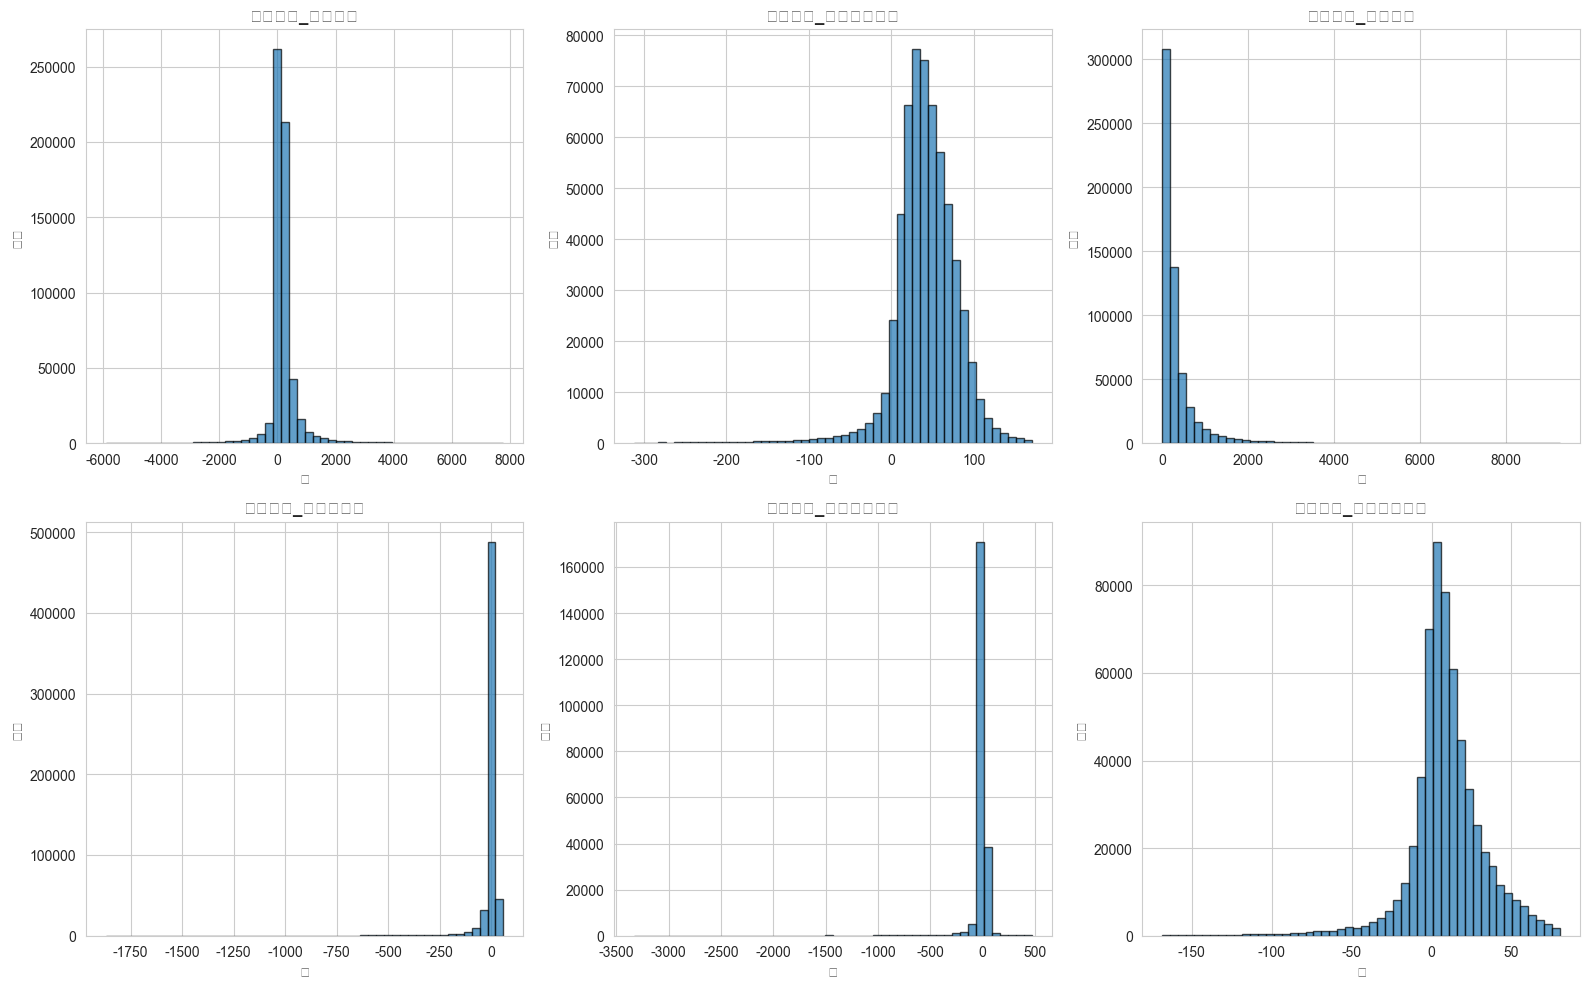

In [23]:
# 재무비율 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_ratios):
    # 이상치 제거 (99.5 percentile)
    data = df[col].dropna()
    upper_limit = data.quantile(0.995)
    lower_limit = data.quantile(0.005)
    filtered_data = data[(data >= lower_limit) & (data <= upper_limit)]
    
    axes[idx].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('값')
    axes[idx].set_ylabel('빈도')

plt.tight_layout()
plt.show()

## 9. 신용등급별 재무비율 비교

<Figure size 1400x600 with 0 Axes>

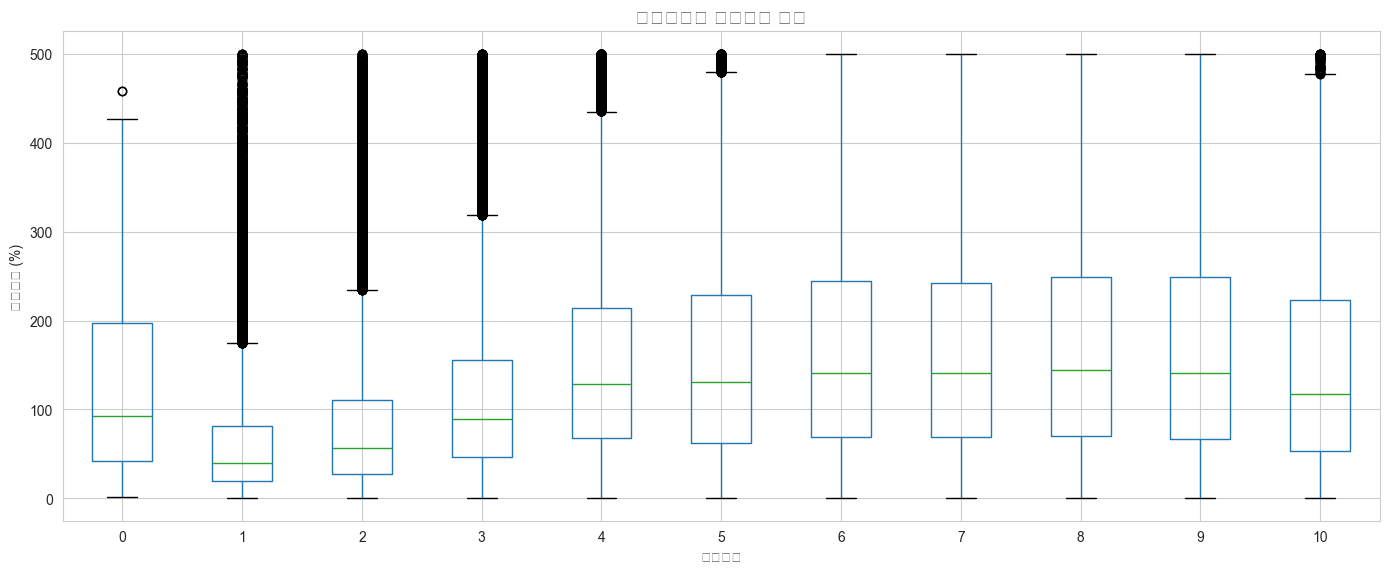

In [24]:
# 신용등급별 부채비율 boxplot
plt.figure(figsize=(14, 6))
df_filtered = df[df['재무비율_부채비율'].between(0, 500)]  # 이상치 제거
df_filtered.boxplot(column='재무비율_부채비율', by='기업신용평가등급(구간화)', figsize=(14, 6))
plt.suptitle('')
plt.title('신용등급별 부채비율 분포', fontsize=14, fontweight='bold')
plt.xlabel('신용등급')
plt.ylabel('부채비율 (%)')
plt.tight_layout()
plt.show()

In [25]:
# 신용등급별 주요 재무비율 평균
grade_ratio_avg = df.groupby('기업신용평가등급(구간화)')[key_ratios].mean()
print("=== 신용등급별 주요 재무비율 평균 ===")
print(grade_ratio_avg.round(2))

=== 신용등급별 주요 재무비율 평균 ===
               재무비율_부채비율  재무비율_자기자본비율  재무비율_유동비율  재무비율_영업이익율  재무비율_당기순이익율  \
기업신용평가등급(구간화)                                                               
0                 152.83        43.42     549.43     -332.70         0.00   
1                  92.11        66.62     635.26       70.87       -12.04   
2                -458.57        59.94     805.70      -83.65       -11.36   
3                 186.86        49.22     547.14      -44.61       -28.81   
4                 260.55        38.76     949.34      -44.46       -15.83   
5                -179.10        34.38     618.42     -132.40       -29.48   
6                 390.03        26.22     649.60    -1008.12      -459.54   
7                   6.50        34.22      58.47     -717.53     -1699.96   
8                 237.33        15.42     655.32     -177.27     -2195.05   
9                 442.09        19.84    -114.43     -195.17      -189.30   
10                173.54         4.55     601.40   

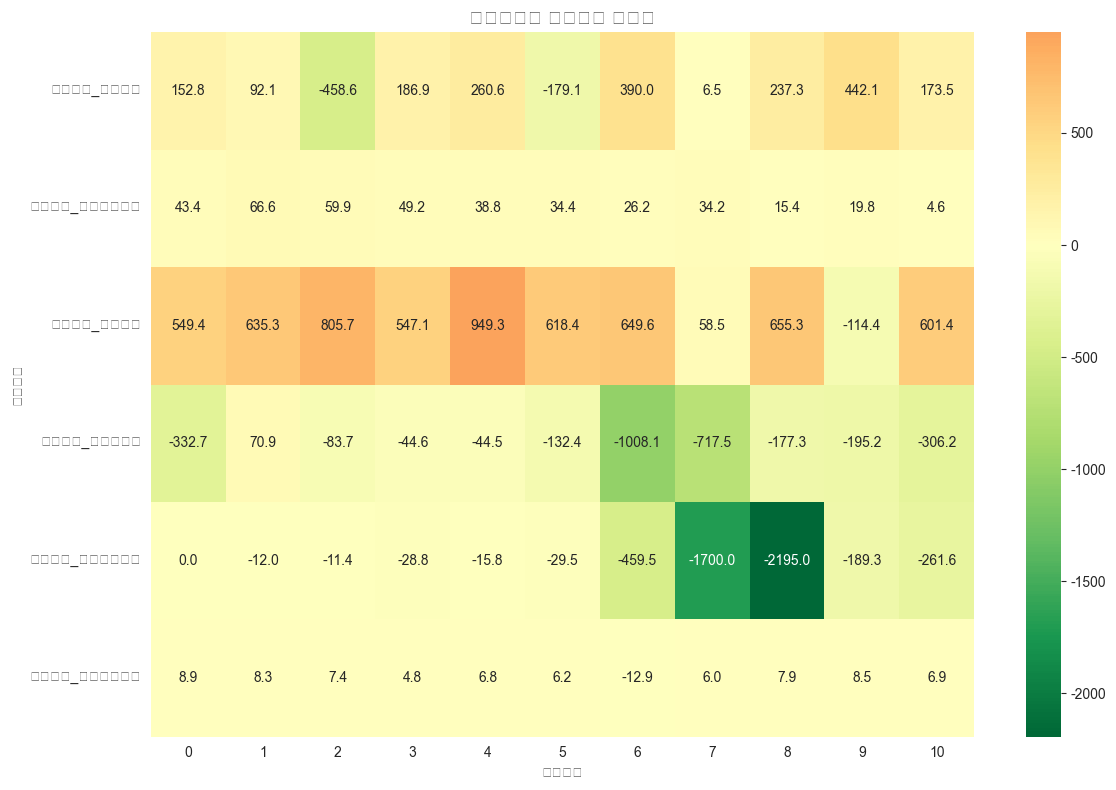

In [26]:
# 히트맵으로 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(grade_ratio_avg.T, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0)
plt.title('신용등급별 재무비율 히트맵', fontsize=14, fontweight='bold')
plt.xlabel('신용등급')
plt.ylabel('재무비율')
plt.tight_layout()
plt.show()

## 10. 부도 기업 vs 정상 기업 재무비율 비교

=== 부도 여부별 재무비율 평균 ===
    재무비율_부채비율  재무비율_자기자본비율  재무비율_유동비율  재무비율_영업이익율  재무비율_당기순이익율  재무비율_총자산증가율
정상      39.77        39.36     615.88     -291.91      -265.92         3.64
부도    3555.51         4.46     619.79     -126.09       -64.07         7.82


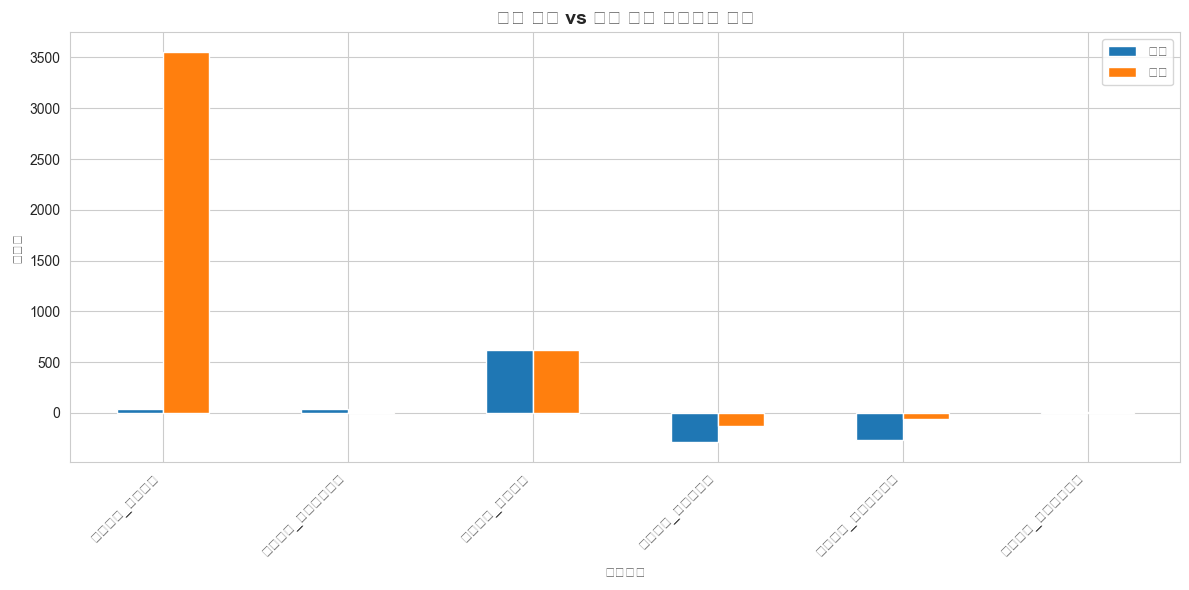

In [27]:
# 부도 여부별 재무비율 평균
default_ratio_avg = df.groupby('모형개발용Performance(향후1년내부도여부)')[key_ratios].mean()
default_ratio_avg.index = ['정상', '부도']
print("=== 부도 여부별 재무비율 평균 ===")
print(default_ratio_avg.round(2))

# 비교 bar plot
default_ratio_avg.T.plot(kind='bar', figsize=(12, 6))
plt.title('부도 기업 vs 정상 기업 재무비율 비교', fontsize=14, fontweight='bold')
plt.xlabel('재무비율')
plt.ylabel('평균값')
plt.xticks(rotation=45, ha='right')
plt.legend(['정상', '부도'])
plt.tight_layout()
plt.show()

## 11. 업종별 재무 특성

In [28]:
# 상위 10개 업종 선정
top_industries = df['업종(중분류)'].value_counts().head(10).index
df_top_ind = df[df['업종(중분류)'].isin(top_industries)]

# 업종별 평균 재무비율
industry_ratio_avg = df_top_ind.groupby('업종(중분류)')[key_ratios].mean()
print("=== 상위 10개 업종별 평균 재무비율 ===")
print(industry_ratio_avg.round(2))

=== 상위 10개 업종별 평균 재무비율 ===
         재무비율_부채비율  재무비율_자기자본비율  재무비율_유동비율  재무비율_영업이익율  재무비율_당기순이익율  \
업종(중분류)                                                               
C10         192.86        34.18     421.99      -35.29       -16.78   
C25        -376.98        42.09     394.24       -6.78        -1.84   
C26         194.44       106.72     392.08      -15.08       -28.67   
C29         225.38        43.43     418.78      -10.57        -6.40   
F41        -224.91        48.78    1134.91     -280.25      -439.38   
F42         133.44        61.77     996.42      -24.96      -272.39   
G46         159.14        39.25     457.97      -29.37       -24.64   
G47        -380.70        25.35     585.49      -51.22        47.87   
J58         172.47        30.74      46.51     -313.64       -37.98   
L68       -1788.41        22.00    1309.94     -529.95      -771.23   

         재무비율_총자산증가율  
업종(중분류)               
C10             8.10  
C25             7.76  
C26             7.82  
C29  

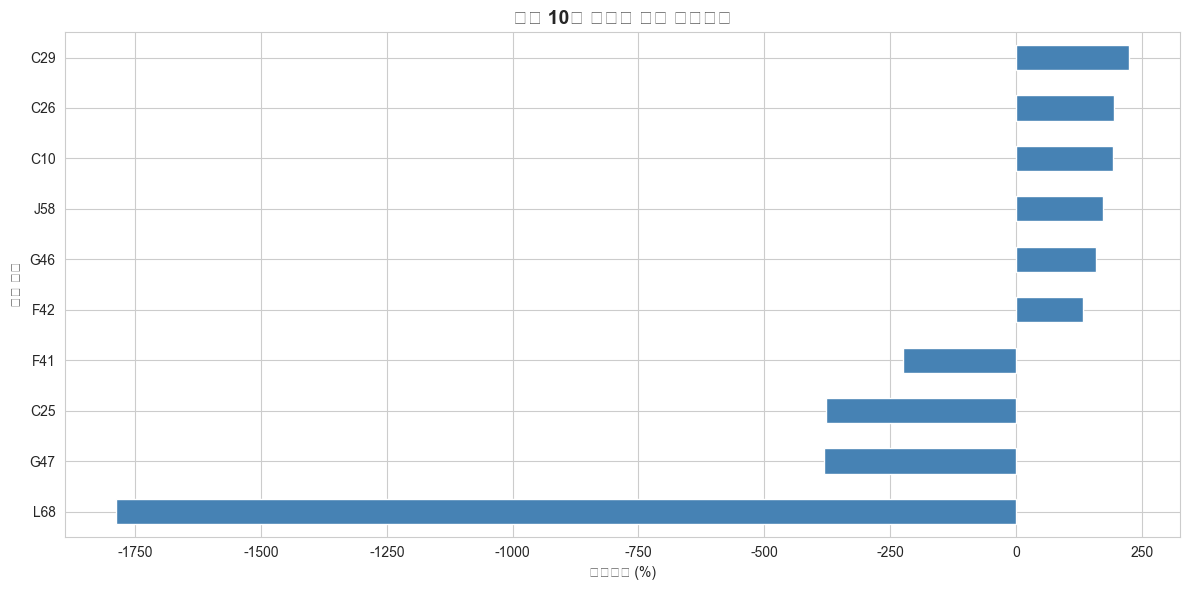

In [29]:
# 업종별 부채비율 비교
plt.figure(figsize=(12, 6))
industry_ratio_avg['재무비율_부채비율'].sort_values().plot(kind='barh', color='steelblue')
plt.title('상위 10개 업종별 평균 부채비율', fontsize=14, fontweight='bold')
plt.xlabel('부채비율 (%)')
plt.ylabel('업종 코드')
plt.tight_layout()
plt.show()

## 12. 결측치 분석

In [30]:
# 결측치 비율
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측수': missing, '비율(%)': missing_pct})
missing_df = missing_df[missing_df['결측수'] > 0]

print("=== 결측치 상위 20개 컬럼 ===")
print(missing_df.head(20))

=== 결측치 상위 20개 컬럼 ===
                 결측수  비율(%)
상장폐지일자        599596  99.93
상장일자          577945  96.32
재무비율_총자산순이익률  378251  63.04
재무비율_당기순이익율   374613  62.44
주소지시군구         49008   8.17
재무비율_유형자산증가율   45305   7.55
재무비율_매입채무회전율   45305   7.55
재무비율_유동자산증가율   45305   7.55
부채상환계수.1       38988   6.50
EBITDA증가율      23856   3.98
영업이익이자보상배율       313   0.05
이자보상배율           313   0.05
업종(중분류)           58   0.01


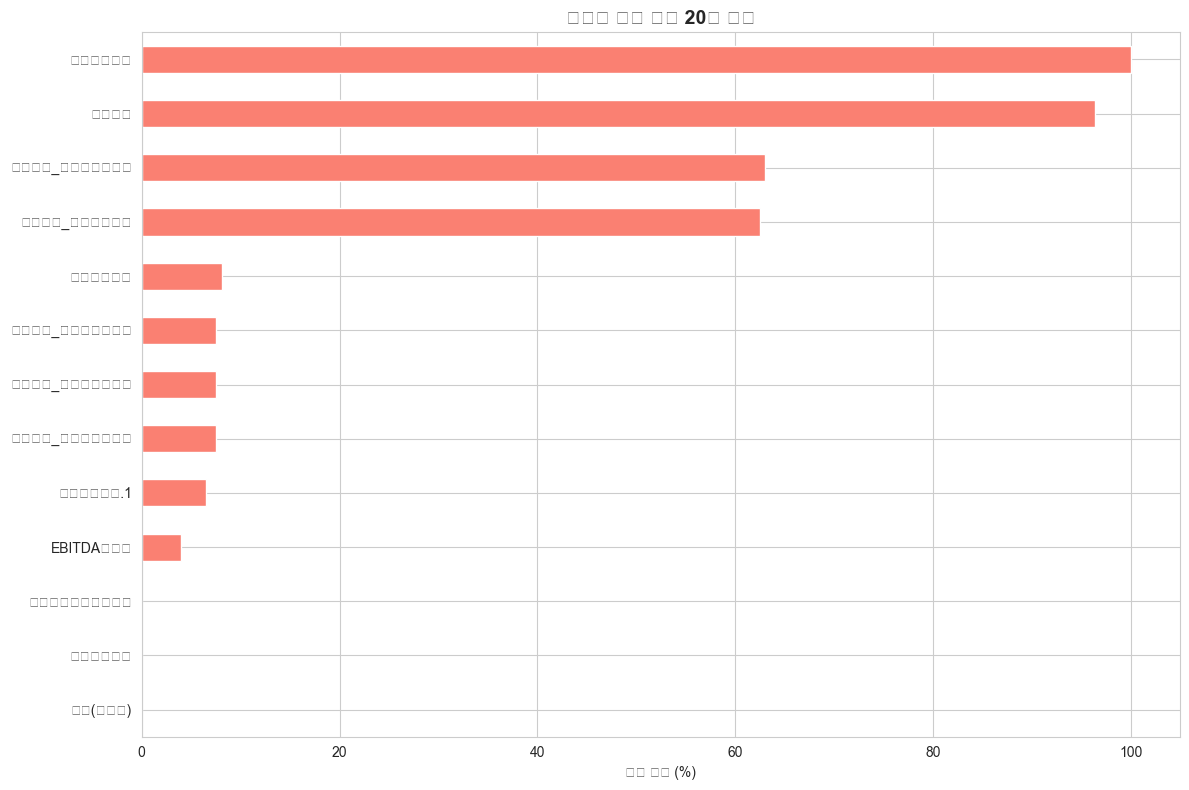

In [31]:
# 결측치 시각화
plt.figure(figsize=(12, 8))
missing_df.head(20)['비율(%)'].plot(kind='barh', color='salmon')
plt.title('결측치 비율 상위 20개 컬럼', fontsize=14, fontweight='bold')
plt.xlabel('결측 비율 (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. 상관관계 분석

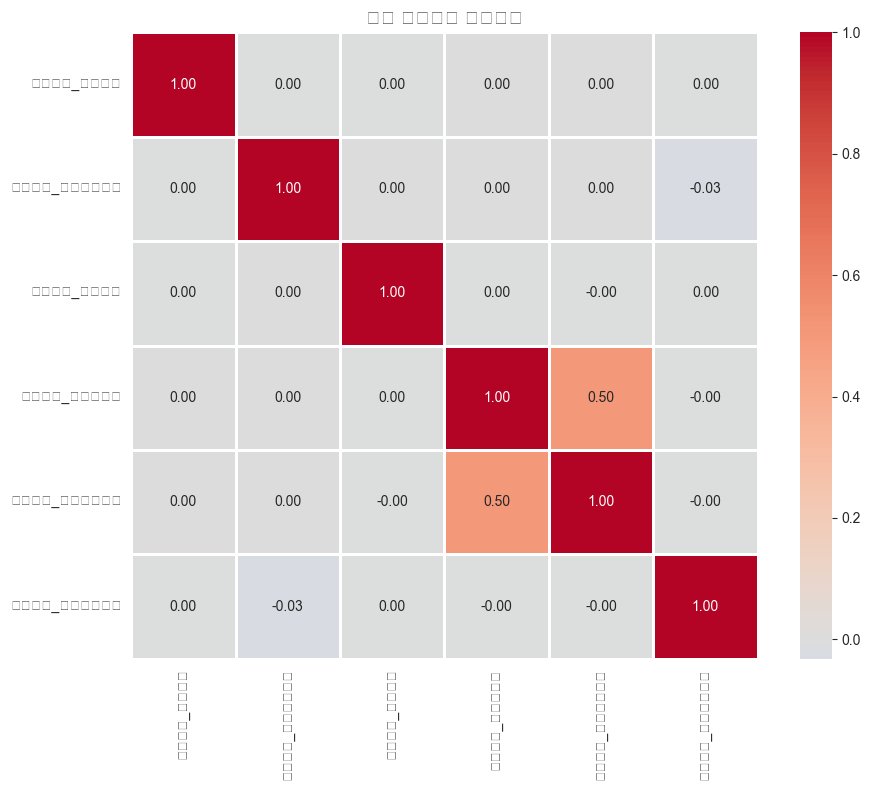

In [32]:
# 주요 재무비율 간 상관관계
corr_matrix = df[key_ratios].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('주요 재무비율 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# 신용등급과의 상관관계
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_grade = df[numeric_cols].corr()['기업신용평가등급(구간화)'].sort_values(ascending=False)

print("=== 신용등급과 상관관계가 높은 변수 (상위 20개) ===")
print(corr_with_grade.head(20))

print("\n=== 신용등급과 상관관계가 낮은 변수 (하위 20개) ===")
print(corr_with_grade.tail(20))

=== 신용등급과 상관관계가 높은 변수 (상위 20개) ===
기업신용평가등급(구간화)                               1.000000
설립일자                                        0.383752
상장폐지일자                                      0.348224
외감구분                                        0.258653
기업신용공여연체최장연체일수(일보)(1년내발생)(해제포함)             0.178764
기업신용공여연체기관수(일보)(3년내유지)(연체일수30일이상)(해제포함)     0.172296
기업신용공여30일이상연체기관수(일보)(해제포함)                  0.158983
모형개발용Performance(향후1년내부도여부)                 0.158894
기업신용공여연체최장연체일수(일보)(3년내발생)(해제포함)             0.156771
기업신용공여연체기관수(일보)(1년내유지)(연체일수30일이상)(해제포함)     0.155854
기업신용공여연체최장연체일수(일보)(6개월내발생)(해제포함)            0.153343
기업신용공여30일이상연체기관수(일보)(연체)(해제포함)              0.146046
기업신용공여연체최장연체일수(일보)(3개월내발생)(해제포함)            0.128893
기업신용공여연체과목수(일보)(1년내유지)(해제포함)                0.125954
기업신용공여연체과목수(일보)(1년내유지)(연체일수30일이상)(해제포함)     0.125152
기업신용공여연체기관수(일보)(6개월내유지)(연체일수30일이상)(해제포함)    0.124548
기업신용공여연체과목수(일보)(1년내발생)(해제포함)                0.121702
기업신용공여연체과목수(일보)(3년내발생)(해제포함)                0.121142
기업신용공여연체과목수

## 14. 시계열 트렌드 분석

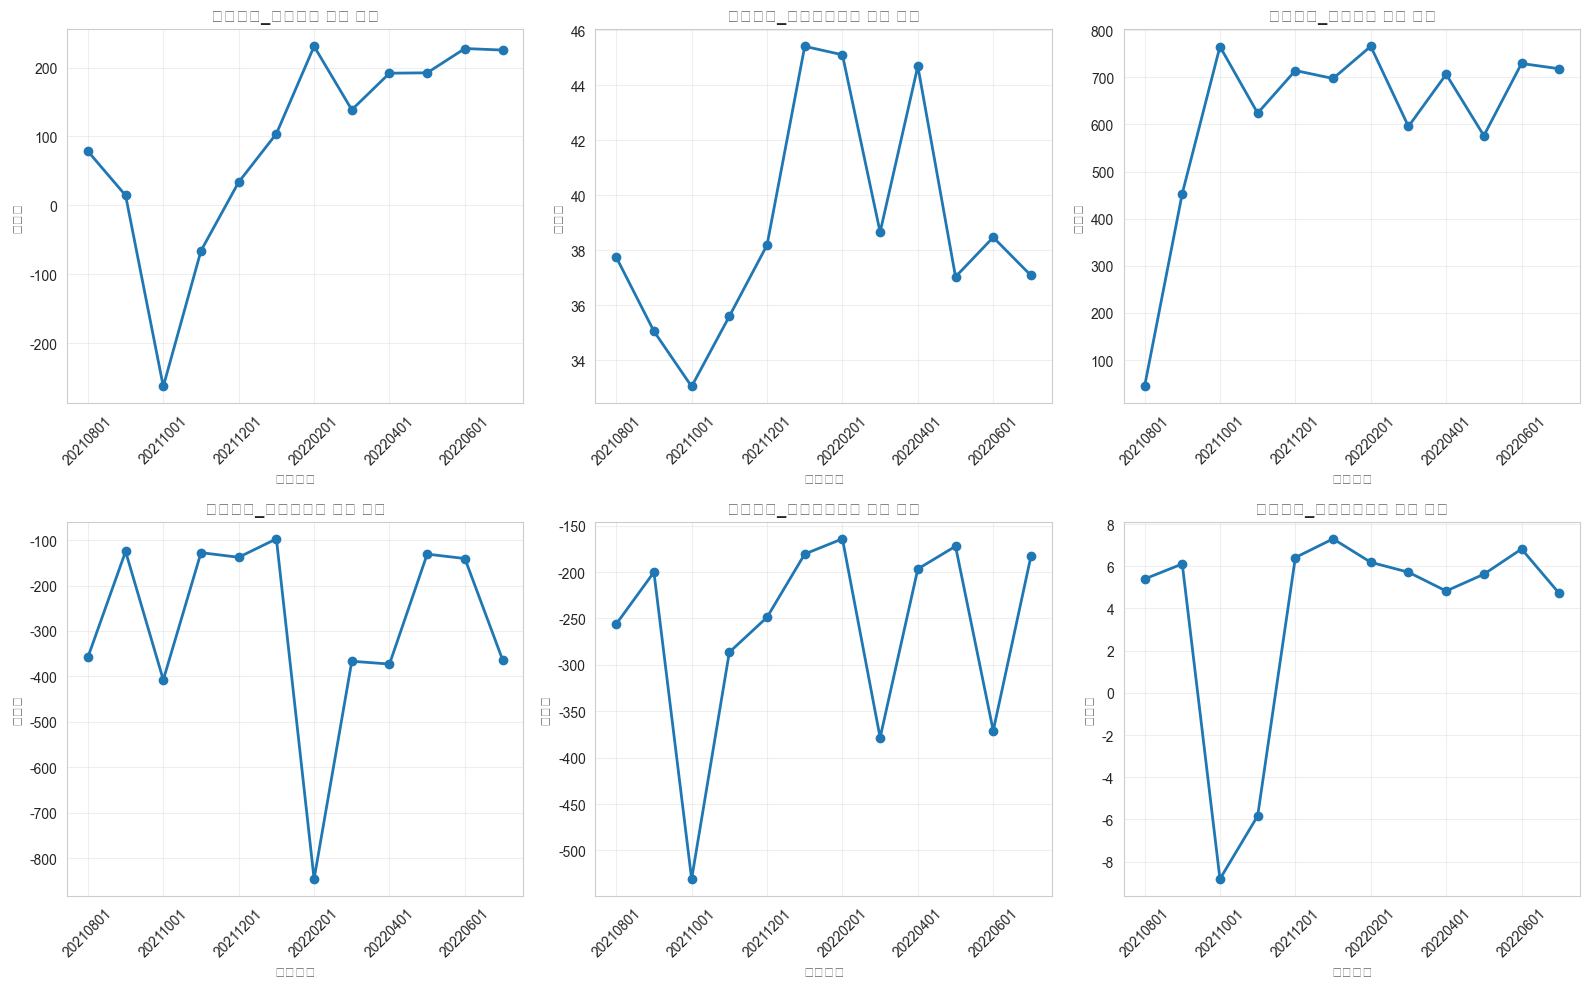

In [34]:
# 월별 평균 재무비율 추이
monthly_avg = df.groupby('기준년월')[key_ratios].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_ratios):
    monthly_avg[col].plot(ax=axes[idx], marker='o', linewidth=2)
    axes[idx].set_title(f'{col} 월별 추이', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('기준년월')
    axes[idx].set_ylabel('평균값')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

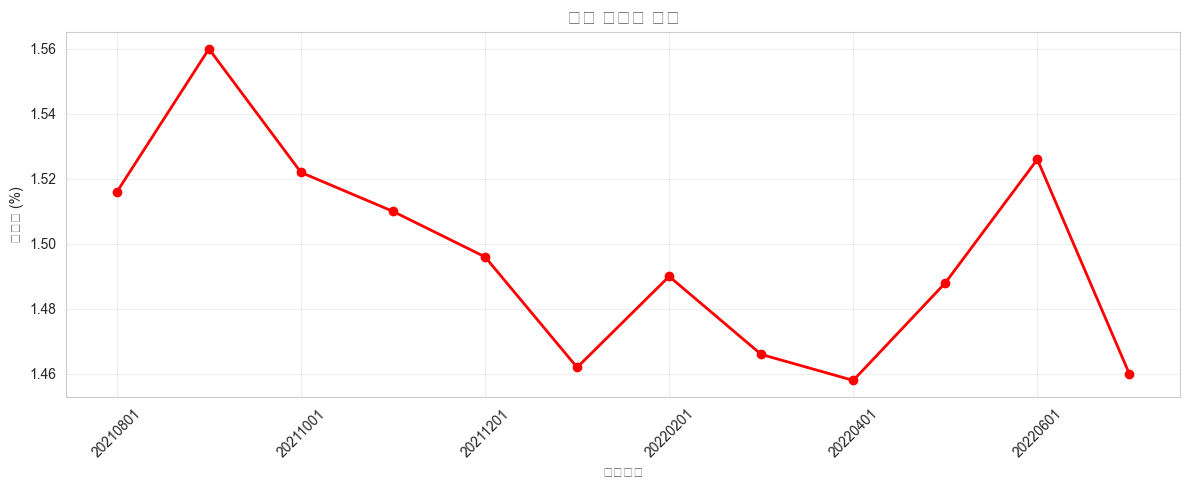

In [35]:
# 월별 부도율 추이
monthly_default = df.groupby('기준년월')['모형개발용Performance(향후1년내부도여부)'].mean() * 100

plt.figure(figsize=(12, 5))
monthly_default.plot(marker='o', linewidth=2, color='red')
plt.title('월별 부도율 추이', fontsize=14, fontweight='bold')
plt.xlabel('기준년월')
plt.ylabel('부도율 (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. 요약 및 인사이트

### 주요 발견사항
1. **데이터 구조**
   - 60만 행, 159개 컬럼
   - 12개월 데이터 (2021.08 ~ 2022.07)
   - 가명식별자 부재 → 시계열 추적 불가

2. **신용등급 분포**
   - [등급별 특성 작성]
   
3. **부도율**
   - 전체 부도율: ~1.5%
   - 신용등급이 낮을수록 부도율 증가
   
4. **재무비율 특성**
   - [주요 인사이트 작성]
   
5. **프로젝트 방향성 제안**
   - [EDA 결과 기반 아이디어 우선순위]

### Next Steps
1. 팀 회의: 프로젝트 방향성 결정
2. Feature Engineering 계획
3. 데이터 파이프라인 설계

## 16. 추가 분석 아이디어

### 향후 심화 분석
1. **클러스터링**
   - K-Means로 기업 군집화
   - 유사 기업 매칭 (아이디어 1)

2. **예측 모델링**
   - 신용등급 예측
   - 부도 예측
   
3. **이상치 탐지**
   - Isolation Forest
   - 재무 건전성 이상 기업 발견
   
4. **업종별 벤치마킹**
   - Percentile 계산
   - API 제공 준비

In [39]:
df.isnull().sum()[df.isnull().sum()>0]

업종(중분류)             58
주소지시군구           49008
상장일자            577945
상장폐지일자          599596
영업이익이자보상배율         313
이자보상배율             313
재무비율_당기순이익율     374613
재무비율_매입채무회전율     45305
재무비율_총자산순이익률    378251
재무비율_유동자산증가율     45305
재무비율_유형자산증가율     45305
EBITDA증가율        23856
부채상환계수.1         38988
dtype: int64

In [44]:
# df[df['자산총계']]
df[df['자산총계']>=500000000000]

,기준년월,업종(중분류),외감구분,설립일자,종업원수,주소지시군구,상장일자,상장폐지일자,유동자산,비유동자산,...,"공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(5년내발생)","신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)","신용도판단정보공공정보최근해제일자로부터경과일수(CIS)(해제,삭제)",기업신용평가등급(구간화),모형개발용Performance(향후1년내부도여부),기준년월_date,pseudo_id,상장여부
0,20220701,C26,1,19690818,116097,41117.0,19750829.0,NaN,1.504270e+11,3.596010e+11,...,0,0,0,999999999,999999999,2,0,2022-07-01,19690818_C26_41117.0_116097,True
1,20220601,C26,1,19690713,121404,41117.0,19741123.0,NaN,1.526740e+11,3.566620e+11,...,0,0,0,999999999,999999999,2,0,2022-06-01,19690713_C26_41117.0_121404,True
2,20220501,C26,1,19690107,125782,41117.0,19741011.0,NaN,1.490870e+11,3.552700e+11,...,0,0,0,999999999,999999999,2,0,2022-05-01,19690107_C26_41117.0_125782,True
3,20220401,C26,1,19690823,116120,41117.0,19741213.0,NaN,1.471070e+11,3.562730e+11,...,0,0,0,999999999,999999999,2,0,2022-04-01,19690823_C26_41117.0_116120,True
4,20220301,C26,1,19681122,121404,41117.0,19750112.0,NaN,1.448420e+11,3.553570e+11,...,0,0,0,999999999,999999999,2,0,2022-03-01,19681122_C26_41117.0_121404,True


In [56]:
df[df['자산총계']<0].iloc[10:,:30]

,기준년월,업종(중분류),외감구분,설립일자,종업원수,주소지시군구,상장일자,상장폐지일자,유동자산,비유동자산,...,매출채권처분손실(당기),무형자산,투자자산,자산총계,자산총계(전기),유동부채,단기차입금,차입금,매입채무,비유동부채
599952,20211001,G45,1,20080706,2,NaN,NaN,NaN,1177923.0,-1673422.0,...,0,845907,0.0,-495499.0,567870.0,4517948.0,2882061,4088530,0,1069502
599953,20211101,J61,2,20170408,155,11545.0,NaN,NaN,-908702.0,384127.0,...,0,0,0.0,-524575.0,567870.0,2041359.0,0,102433,0,752899
599954,20210901,J61,2,20170422,155,11545.0,NaN,NaN,-908702.0,384127.0,...,0,0,0.0,-524575.0,567870.0,2041359.0,0,102433,0,752899
599955,20220501,C26,1,19970220,91,41271.0,NaN,NaN,18578781.0,-24526150.0,...,0,53118,2963355.0,-5947369.0,567870.0,82830968.0,12505482,18251322,2435345,2506439
599956,20220401,C26,1,19970728,91,41271.0,NaN,NaN,18578781.0,-24526150.0,...,0,53118,2963355.0,-5947369.0,567870.0,82830968.0,12505482,18251322,2435345,2506439
599957,20220301,C26,1,19970829,91,41271.0,NaN,NaN,18578781.0,-24526150.0,...,0,53118,2963355.0,-5947369.0,567870.0,82830968.0,12505482,18251322,2435345,2506439
599958,20211101,R91,1,20130821,96,43750.0,NaN,NaN,21310599.0,-31199334.0,...,121253,1083575,30000000.0,-9888735.0,567870.0,282291097.0,0,92524789,4090671,110692644
599959,20211201,R91,1,20121226,96,43750.0,NaN,NaN,21310599.0,-31199334.0,...,121253,1083575,30000000.0,-9888735.0,567870.0,282291097.0,0,92524789,4090671,110692644
599960,20210901,R91,1,20130612,96,43750.0,NaN,NaN,21310599.0,-31199334.0,...,121253,1083575,30000000.0,-9888735.0,567870.0,282291097.0,0,92524789,4090671,110692644
599961,20211001,C28,1,20070424,460,45710.0,NaN,NaN,1380223.0,-16252256.0,...,0,5,0.0,-14872033.0,567870.0,10614082.0,5464012,7907837,731064,3240712


### 컬럼 상태 확인 

In [57]:
pd.set_option('display.max_columns', None)

In [58]:
df

,기준년월,업종(중분류),외감구분,설립일자,종업원수,주소지시군구,상장일자,상장폐지일자,유동자산,비유동자산,당좌자산,재고자산,유형자산,재공품,현금,현금등가물,상품유가증권,현금성자산,매출채권,매출채권(전기),매출채권처분손실(당기),무형자산,투자자산,자산총계,자산총계(전기),유동부채,단기차입금,차입금,매입채무,비유동부채,부채총계,자기자본(납입자본금),자본잉여금,납입자본,이익잉여금,자본조정,기타포괄손익누계액,유보금,자본총계,전기자본총계,매출액,전기매출액,매출원가,매출총이익,판매비와관리비,법인세비용차감전순이익,전기법인세차감전순이익,법인세,계속사업이익,중단산업손익,금융비용,영업손익,전기영업이익,영업외수익,영업외비용,법인세차감전순이익,당기순이익,당기순이익(전기),현금흐름,영업활동현금흐름,투자활동현금흐름,재무활동현금흐름,부채상환계수,영업이익이자보상배율,이자비용,사채이자(당기),이자보상배율,적립금비율,EBIT,EBITDA,청산가치율,청산가치,순운전자본,순차입금,재무비율_총자산증가율,재무비율_부채비율,재무비율_자기자본비율,재무비율_유동비율,재무비율_차입금의존도,재무비율_매출액증가율,재무비율_영업이익율,재무비율_당기순이익율,재무비율_매출원가율,재무비율_판관비율,재무비율_자기자본이익률(ROE),재무비율_매출채권회전율,재무비율_재고자산회전율,재무비율_매입채무회전율,재무비율_총자산회전율,재무비율_총자산순이익률,재무비율_유동자산증가율,재무비율_유형자산증가율,단기차입금의존도,당좌비율,순차입금비율,순운전자본회전율,총자본회전율,자기자본순이익율,매출총이익율,EBITDA마진율,영업이익증가율,당기순이익증가율,EBITDA증가율,OCF/매출액비용,부채상환계수.1,차입금/EBITDA,EBITDA/금융비용,사업장소유여부,소유건축물건수,소유건축물실거래가합계,사업장권리침해여부,소유건축물권리침해여부,기업신용공여연체과목수(일보)(미해제),기업신용공여연체과목수(일보)(3개월내유지)(해제포함),기업신용공여연체과목수(일보)(6개월내유지)(해제포함),기업신용공여연체과목수(일보)(1년내유지)(해제포함),기업신용공여연체과목수(일보)(3년내유지)(해제포함),기업신용공여연체과목수(일보)(3개월내발생)(해제포함),기업신용공여연체과목수(일보)(6개월내발생)(해제포함),기업신용공여연체과목수(일보)(1년내발생)(해제포함),기업신용공여연체과목수(일보)(3년내발생)(해제포함),기업신용공여연체과목수(일보)(3개월내유지)(연체일수30일이상)(해제포함),기업신용공여연체과목수(일보)(6개월내유지)(연체일수30일이상)(해제포함),기업신용공여연체과목수(일보)(1년내유지)(연체일수30일이상)(해제포함),기업신용공여연체과목수(일보)(3년내유지)(연체일수30일이상)(해제포함),기업신용공여30일이상연체과목수(일보)(해제포함),기업신용공여30일이상연체과목수(일보)(미해제),기업신용공여30일이상연체과목수(일보)(이자연체)(해제포함),기업신용공여30일이상연체과목수(일보)(이자연체)(미해제),기업신용공여연체기관수(일보)(미해제),기업신용공여30일이상연체기관수(일보)(해제포함),기업신용공여30일이상연체기관수(일보)(미해제),기업신용공여30일이상연체기관수(일보)(연체)(해제포함),기업신용공여30일이상연체기관수(일보)(이자연체)(미해제),기업신용공여연체기관수(일보)(3개월내유지)(연체일수30일이상)(해제포함),기업신용공여연체기관수(일보)(6개월내유지)(연체일수30일이상)(해제포함),기업신용공여연체기관수(일보)(1년내유지)(연체일수30일이상)(해제포함),기업신용공여연체기관수(일보)(3년내유지)(연체일수30일이상)(해제포함),기업신용공여연체최장연체일수(일보)(3개월내유지)(해제포함),기업신용공여연체최장연체일수(일보)(6개월내유지)(해제포함),기업신용공여연체최장연체일수(일보)(1년내유지)(해제포함),기업신용공여연체최장연체일수(일보)(3년내유지)(해제포함),기업신용공여연체최장연체일수(일보)(5년내유지)(해제포함),기업신용공여연체최장연체일수(일보)(3개월내발생)(해제포함),기업신용공여연체최장연체일수(일보)(6개월내발생)(해제포함),기업신용공여연체최장연체일수(일보)(1년내발생)(해제포함),기업신용공여연체최장연체일수(일보)(3년내발생)(해제포함),기업신용공여연체최장연체일수(일보)(5년내발생)(해제포함),신용도판단공공정보건수(CIS)(5년내발생)(해제포함),신용도판단정보공공정보건수(CIS)(미해제),신용도판단정보공공정보건수(관련인제외)(CIS)(당월유지)(해제포함),"공공정보(국세,지방세,관세체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(5년내발생)","신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)","신용도판단정보공공정보최근해제일자로부터경과일수(CIS)(해제,삭제)",기업신용평가등급(구간화),모형개발용Performance(향후1년내부도여부),기준년월_date,pseudo_id,상장여부
0,20220701,C26,1,19690818,116097,41117.0,19750829.0,NaN,1.504270e+11,3.596010e+11,1.192400e+11,31186582315,2.104230e+11,0,0,0,0,7693638790,63793229442,49503853960,0,16515976358,1.223270e+11,5.100280e+11,4.590590e+11,1.065850e+11,18408536000,18759826621,22642680978,9037924930,1.156230e+11,1867521000,8814807437,10682328437,3.730910e+11,3596614184,-5146667162,3.819060e+11,3.822240e+11,3.665250e+11,3.867000e+11,3.323920e+11,2.716470e+11,1.150530e+11,63371362660,51681823195,40909869860,10066715704,55037767491,0,301361187,51681823195,40909869860,22311966000,8889306000,65104483195,55037767491,31224802100,10665719382,1.040630e+11,-46515056124,-46882287800,1.580641e+00,2.660000e-10,295646023,0,2.660000e-10,20366.891930,34386833218,9.892089e+10,70.751048,3.608500e+11,43842230654,-18536071000,9.993377,30.250038,74.941637,141.133649,3.916103,16.338690,13.364835,14.232677,70.247435,16.387731,0.143994,6.826302,8.710376,9221303.00,0.798071,10.791122,0.010192,25.596799,3.609317,111.873780,-4.849537,8.820264,1.011712,14.701279,29.752565,13.442766,26.330940,76.262983,86.57,26.910538,1.580641,0.0,328.246944,0,723,121649844,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,999999999,999999999,2,0,2022-07-01,19690818_C26_41117.0_116097,True
1,20220601,C26,1,19690713,121404,41117.0,19741123.0,NaN,1.526740e+11,3.566620e+11,1.207270e+11,31946106000,2.073340e+11,0,0,0,0,7912427804,63948008392,49503853960,0,16508596238,1.232650e+11,5.093360e+11,4.590590e+11,1.032010e+11,17923778959,19621572070,22185148267,10185614075,1.133870e+11,177290

In [63]:
df['감가상각누계액']

KeyError: '감가상각누계액'

In [17]:
df

,기준년월,업종(중분류),외감구분,설립일자,종업원수,주소지시군구,상장일자,상장폐지일자,유동자산,비유동자산,...,"공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(미해제)","공공정보(국세,지방세,관세체납,고용산재체납)건수(CIS)(5년내발생)","신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)","신용도판단정보공공정보최근해제일자로부터경과일수(CIS)(해제,삭제)",기업신용평가등급(구간화),모형개발용Performance(향후1년내부도여부),기준년월_date,pseudo_id,상장여부
0,20220701,C26,1,19690818,116097,41117.0,19750829.0,NaN,1.504270e+11,3.596010e+11,...,0,0,0,999999999,999999999,2,0,2022-07-01,19690818_C26_41117.0_116097,True
1,20220601,C26,1,19690713,121404,41117.0,19741123.0,NaN,1.526740e+11,3.566620e+11,...,0,0,0,999999999,999999999,2,0,2022-06-01,19690713_C26_41117.0_121404,True
2,20220501,C26,1,19690107,125782,41117.0,19741011.0,NaN,1.490870e+11,3.552700e+11,...,0,0,0,999999999,999999999,2,0,2022-05-01,19690107_C26_41117.0_125782,True
3,20220401,C26,1,19690823,116120,41117.0,19741213.0,NaN,1.471070e+11,3.562730e+11,...,0,0,0,999999999,999999999,2,0,2022-04-01,19690823_C26_41117.0_116120,True
4,20220301,C26,1,19681122,121404,41117.0,19750112.0,NaN,1.448420e+11,3.553570e+11,...,0,0,0,999999999,999999999,2,0,2022-03-01,19681122_C26_41117.0_121404,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,20220701,H52,1,20180105,15,NaN,NaN,NaN,2.148230e+07,-1.650621e+08,...,0,0,0,999999999,999999999,4,0,2022-07-01,20180105_H52_nan_15,False
599996,20220501,F41,1,20150302,98,28237.0,NaN,NaN,1.513349e+07,-1.620054e+08,...,0,0,0,999999999,999999999,4,0,2022-05-01,20150302_F41_28237.0_98,False
599997,20220301,C22,1,20040707,50,11470.0,NaN,NaN,2.156300e+07,-1.818125e+08,...,0,0,0,999999999,999999999,1,0,2022-03-01,20040707_C22_11470.0_50,False
599998,20210901,C26,1,19720407,12,47190.0,19970119.0,20110613.0,2.431177e+06,-1.885779e+08,...,0,0,0,1770,1680,7,0,2021-09-01,19720407_C26_47190.0_12,True


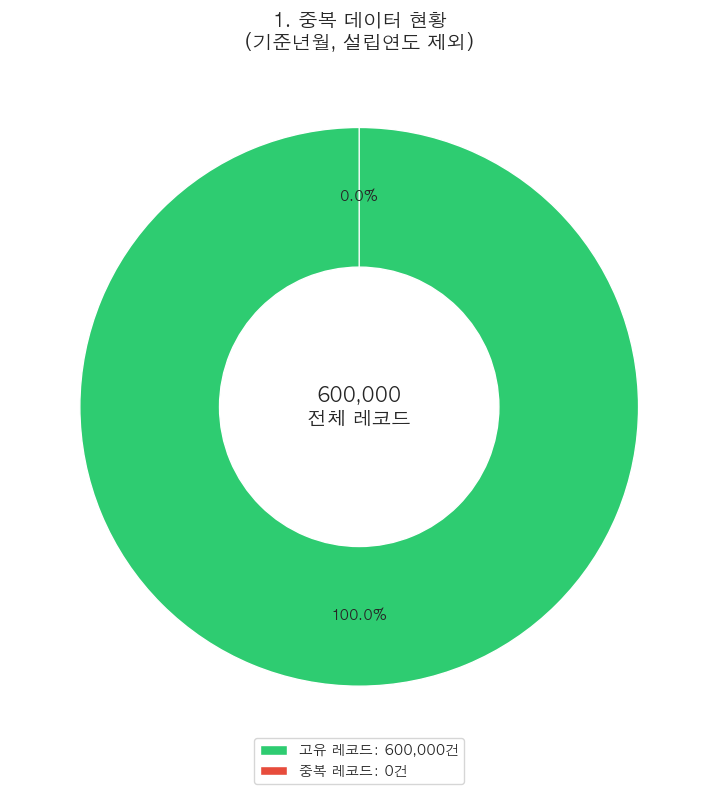

In [21]:

# ============================================================
# EDA 데이터 품질 시각화 코드
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (DW 테이블에서)
# df = pd.read_parquet('data/raw/cb_data.parquet')  # 실제 경로로 변경

# ============================================================
# 1. 중복 데이터 확인 (기준년월, 설립일자 제외)
# ============================================================
exclude_cols = ['기준년월', '설립일자']
check_cols = [col for col in df.columns if col not in exclude_cols]

# 중복 확인
duplicates = df.duplicated(subset=check_cols, keep=False)
n_duplicates = duplicates.sum()
n_unique = len(df) - df.duplicated(subset=check_cols, keep='first').sum()

# 시각화: 도넛 차트
fig, ax = plt.subplots(figsize=(8, 8))
sizes = [len(df) - n_duplicates//2, n_duplicates//2]  # 중복 그룹 수
colors = ['#2ecc71', '#e74c3c']
labels = [f'고유 레코드: {sizes[0]:,}건', f'중복 레코드: {sizes[1]:,}건']

wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%',
                                    startangle=90, pctdistance=0.75,
                                    wedgeprops=dict(width=0.5, edgecolor='white'))
ax.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05))
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, f'{len(df):,}\n전체 레코드', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('1. 중복 데이터 현황\n(기준년월, 설립연도 제외)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_1_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()





In [ ]:

# ============================================================
# 2. 경과일수 컬럼 분포 (999999999 = 이벤트 없음)
# ============================================================
# 경과일수 컬럼들
days_cols = ['DA0D00033_1', 'DA0D00034_1', 'DA0D00035_1', 'D2B000002', 'D2B000003']
days_names = ['연체경과일수(3개월)', '연체경과일수(6개월)', '연체경과일수(1년)',
            '공공정보발생경과일수', '공공정보해제경과일수']

# 대표로 DA0D00035_1 (연체최장경과일수 1년) 사용
col = 'DA0D00035_1'
col_name = '연체최장경과일수(1년내)'

# 999999999 vs 실제값 분리
special_value = 999999999
n_special = (df[col] == special_value).sum()
n_normal = (df[col] != special_value).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 특수값 vs 실제값 비율
ax1 = axes[0]
categories = ['이벤트 없음\n(999999999)', '실제 경과일수']
values = [n_special, n_normal]
colors = ['#f39c12', '#3498db']
bars = ax1.bar(categories, values, color=colors, edgecolor='black')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax1.set_ylabel('기업 수')
ax1.set_title(f'{col_name} 값 분포', fontsize=12, fontweight='bold')

# 오른쪽: 실제 경과일수 분포 (999999999 제외)
ax2 = axes[1]
actual_days = df[df[col] != special_value][col]
ax2.hist(actual_days, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(actual_days.median(), color='red', linestyle='--', label=f'중앙값: {actual_days.median():.0f}일')
ax2.set_xlabel('경과일수')
ax2.set_ylabel('기업 수')
ax2.set_title(f'{col_name} 히스토그램\n(실제값만, 999999999 제외)', fontsize=12, fontweight='bold')
ax2.legend()

plt.suptitle('2. 경과일수 컬럼 분석 (999999999 = 이벤트 없음)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_2_days_elapsed.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:

# ============================================================
# 3. 음수가 존재하면 안 되는 컬럼에 음수값 확인
# ============================================================
# 물리적으로 음수가 불가능한 컬럼들 (자산, 부채, 매출 등)
non_negative_cols = {
    'FN1_13': '자산총계',
    'FN1_19': '부채총계',
    'FN1_24': '자본총계',
    'FN2_1': '매출액',
    'FN1_4': '재고자산',
    'FN1_15': '단기차입금'
}

# 음수 개수 집계
negative_counts = {}
for col, name in non_negative_cols.items():
    if col in df.columns:
        n_negative = (df[col] < 0).sum()
        if n_negative > 0:
            negative_counts[name] = n_negative

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
if negative_counts:
    sorted_items = sorted(negative_counts.items(), key=lambda x: x[1], reverse=True)
    names = [item[0] for item in sorted_items]
    counts = [item[1] for item in sorted_items]

    colors = plt.cm.Reds(np.linspace(0.4, 0.8, len(names)))
    bars = ax.barh(names, counts, color=colors, edgecolor='black')

    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{count:,}건 ({count/len(df)*100:.2f}%)', va='center', fontsize=10)

    ax.set_xlabel('음수값 건수')
    ax.set_title('3. 음수가 존재하면 안 되는 컬럼의 음수값 현황', fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(counts) * 1.3)
else:
    ax.text(0.5, 0.5, '음수값이 발견되지 않았습니다', ha='center', va='center', fontsize=14)
    ax.set_title('3. 음수값 확인 결과', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_3_negative_values.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
 ============================================================
# 4. 이상치 분석 (IQR 방식)
# ============================================================
# 주요 재무 컬럼
outlier_cols = {
    'FN1_13': '자산총계',
    'FN2_1': '매출액',
    'R006': '부채비율',
    'R018': 'ROE',
    'R008': '유동비율'
}

# IQR 이상치 계산
outlier_summary = []
for col, name in outlier_cols.items():
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary.append({
            'name': name,
            'col': col,
            'n_outliers': n_outliers,
            'pct': n_outliers / len(df) * 100
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=True)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 이상치 건수 막대그래프
ax1 = axes[0]
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.8, len(outlier_df)))
bars = ax1.barh(outlier_df['name'], outlier_df['n_outliers'], color=colors, edgecolor='black')
for bar, pct in zip(bars, outlier_df['pct']):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)
ax1.set_xlabel('이상치 건수')
ax1.set_title('IQR 기준 이상치 건수 (IQR × 1.5)', fontsize=12, fontweight='bold')

# 오른쪽: 대표 컬럼 박스플롯
ax2 = axes[1]
sample_col = 'R006'  # 부채비율
if sample_col in df.columns:
    # 극단값 제외한 범위로 시각화
    Q1, Q3 = df[sample_col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    plot_data = df[(df[sample_col] >= Q1 - 3*IQR) & (df[sample_col] <= Q3 + 3*IQR)][sample_col]
    ax2.boxplot(plot_data, vert=True)
    ax2.set_ylabel('부채비율 (%)')
    ax2.set_title(f'부채비율(R006) 박스플롯\n(극단 이상치 제외)', fontsize=12, fontweight='bold')

plt.suptitle('4. 이상치 분석 (IQR × 1.5 기준)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_4_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# 5. 파생컬럼(재무비율) 결측치 현황
# ============================================================
# 파생 컬럼 (재무비율)
derived_cols = {
    'R006': '부채비율',
    'R007': '자기자본비율',
    'R008': '유동비율',
    'R018': 'ROE',
    'R015': '영업이익율',
    'R016': '당기순이익율',
    'N003': '순운전자본회전율',
    'N006': 'EBITDA마진율'
}

# 결측치 집계
missing_counts = {}
for col, name in derived_cols.items():
    if col in df.columns:
        n_missing = df[col].isna().sum()
        if n_missing > 0:
            missing_counts[name] = n_missing

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
if missing_counts:
    sorted_items = sorted(missing_counts.items(), key=lambda x: x[1], reverse=True)
    names = [item[0] for item in sorted_items]
    counts = [item[1] for item in sorted_items]

    colors = plt.cm.Purples(np.linspace(0.4, 0.8, len(names)))
    bars = ax.barh(names, counts, color=colors, edgecolor='black')

    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{count:,}건 ({count/len(df)*100:.1f}%)', va='center', fontsize=10)

    ax.set_xlabel('결측치 건수')
    ax.set_title('5. 파생컬럼(재무비율) 결측치 현황\n(0으로 나누기 등으로 인한 계산 불가)',
                fontsize=14, fontweight='bold')
else:
    ax.text(0.5, 0.5, '결측치가 발견되지 않았습니다', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('eda_5_missing_derived.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 5개 시각화 완료!")


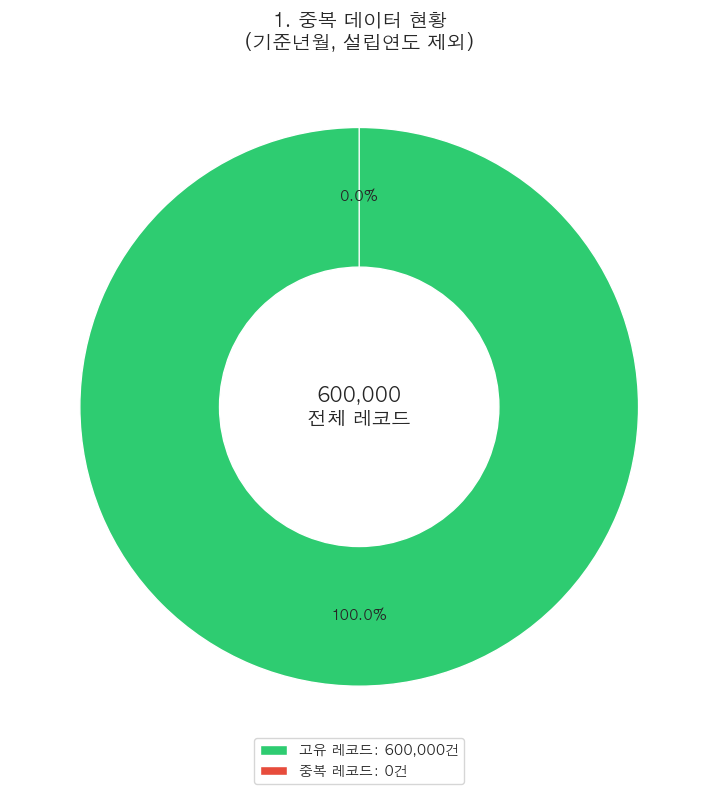

KeyError: 'DA0D00035_1'

In [18]:

  # ============================================================
  # EDA 데이터 품질 시각화 코드
  # ============================================================

  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns

  # 한글 폰트 설정
  plt.rcParams['font.family'] = 'AppleGothic'
  plt.rcParams['axes.unicode_minus'] = False

  # 데이터 로드 (DW 테이블에서)
  # df = pd.read_parquet('data/raw/cb_data.parquet')  # 실제 경로로 변경

  # ============================================================
  # 1. 중복 데이터 확인 (기준년월, 설립연도 제외)
  # ============================================================
  exclude_cols = ['BS_DT', 'FNDT_DT', 'COMPANY_ID', 'COMPANY_SK', 'TIME_SK']
  check_cols = [col for col in df.columns if col not in exclude_cols]

  # 중복 확인
  duplicates = df.duplicated(subset=check_cols, keep=False)
  n_duplicates = duplicates.sum()
  n_unique = len(df) - df.duplicated(subset=check_cols, keep='first').sum()

  # 시각화: 도넛 차트
  fig, ax = plt.subplots(figsize=(8, 8))
  sizes = [len(df) - n_duplicates//2, n_duplicates//2]  # 중복 그룹 수
  colors = ['#2ecc71', '#e74c3c']
  labels = [f'고유 레코드: {sizes[0]:,}건', f'중복 레코드: {sizes[1]:,}건']

  wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%',
                                     startangle=90, pctdistance=0.75,
                                     wedgeprops=dict(width=0.5, edgecolor='white'))
  ax.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05))
  centre_circle = plt.Circle((0, 0), 0.35, fc='white')
  ax.add_patch(centre_circle)
  ax.text(0, 0, f'{len(df):,}\n전체 레코드', ha='center', va='center', fontsize=14, fontweight='bold')
  ax.set_title('1. 중복 데이터 현황\n(기준년월, 설립연도 제외)', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.savefig('eda_1_duplicates.png', dpi=150, bbox_inches='tight')
  plt.show()


  # ============================================================
  # 2. 경과일수 컬럼 분포 (999999999 = 이벤트 없음)
  # ============================================================
  # 경과일수 컬럼들
  days_cols = ['DA0D00033_1', 'DA0D00034_1', 'DA0D00035_1', 'D2B000002', 'D2B000003']
  days_names = ['연체경과일수(3개월)', '연체경과일수(6개월)', '연체경과일수(1년)',
                '공공정보발생경과일수', '공공정보해제경과일수']

  # 대표로 DA0D00035_1 (연체최장경과일수 1년) 사용
  col = 'DA0D00035_1'
  col_name = '연체최장경과일수(1년내)'

  # 999999999 vs 실제값 분리
  special_value = 999999999
  n_special = (df[col] == special_value).sum()
  n_normal = (df[col] != special_value).sum()

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # 왼쪽: 특수값 vs 실제값 비율
  ax1 = axes[0]
  categories = ['이벤트 없음\n(999999999)', '실제 경과일수']
  values = [n_special, n_normal]
  colors = ['#f39c12', '#3498db']
  bars = ax1.bar(categories, values, color=colors, edgecolor='black')
  for bar, val in zip(bars, values):
      ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
               f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
  ax1.set_ylabel('기업 수')
  ax1.set_title(f'{col_name} 값 분포', fontsize=12, fontweight='bold')

  # 오른쪽: 실제 경과일수 분포 (999999999 제외)
  ax2 = axes[1]
  actual_days = df[df[col] != special_value][col]
  ax2.hist(actual_days, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
  ax2.axvline(actual_days.median(), color='red', linestyle='--', label=f'중앙값: {actual_days.median():.0f}일')
  ax2.set_xlabel('경과일수')
  ax2.set_ylabel('기업 수')
  ax2.set_title(f'{col_name} 히스토그램\n(실제값만, 999999999 제외)', fontsize=12, fontweight='bold')
  ax2.legend()

  plt.suptitle('2. 경과일수 컬럼 분석 (999999999 = 이벤트 없음)', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.savefig('eda_2_days_elapsed.png', dpi=150, bbox_inches='tight')
  plt.show()


  # ============================================================
  # 3. 음수가 존재하면 안 되는 컬럼에 음수값 확인
  # ============================================================
  # 물리적으로 음수가 불가능한 컬럼들 (자산, 부채, 매출 등)
  non_negative_cols = {
      'FN1_13': '자산총계',
      'FN1_19': '부채총계',
      'FN1_24': '자본총계',
      'FN2_1': '매출액',
      'FN1_4': '재고자산',
      'FN1_15': '단기차입금'
  }

  # 음수 개수 집계
  negative_counts = {}
  for col, name in non_negative_cols.items():
      if col in df.columns:
          n_negative = (df[col] < 0).sum()
          if n_negative > 0:
              negative_counts[name] = n_negative

  # 시각화
  fig, ax = plt.subplots(figsize=(10, 6))
  if negative_counts:
      sorted_items = sorted(negative_counts.items(), key=lambda x: x[1], reverse=True)
      names = [item[0] for item in sorted_items]
      counts = [item[1] for item in sorted_items]

      colors = plt.cm.Reds(np.linspace(0.4, 0.8, len(names)))
      bars = ax.barh(names, counts, color=colors, edgecolor='black')

      for bar, count in zip(bars, counts):
          ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                  f'{count:,}건 ({count/len(df)*100:.2f}%)', va='center', fontsize=10)

      ax.set_xlabel('음수값 건수')
      ax.set_title('3. 음수가 존재하면 안 되는 컬럼의 음수값 현황', fontsize=14, fontweight='bold')
      ax.set_xlim(0, max(counts) * 1.3)
  else:
      ax.text(0.5, 0.5, '음수값이 발견되지 않았습니다', ha='center', va='center', fontsize=14)
      ax.set_title('3. 음수값 확인 결과', fontsize=14, fontweight='bold')

  plt.tight_layout()
  plt.savefig('eda_3_negative_values.png', dpi=150, bbox_inches='tight')
  plt.show()


  # ============================================================
  # 4. 이상치 분석 (IQR 방식)
  # ============================================================
  # 주요 재무 컬럼
  outlier_cols = {
      'FN1_13': '자산총계',
      'FN2_1': '매출액',
      'R006': '부채비율',
      'R018': 'ROE',
      'R008': '유동비율'
  }

  # IQR 이상치 계산
  outlier_summary = []
  for col, name in outlier_cols.items():
      if col in df.columns:
          Q1 = df[col].quantile(0.25)
          Q3 = df[col].quantile(0.75)
          IQR = Q3 - Q1
          lower = Q1 - 1.5 * IQR
          upper = Q3 + 1.5 * IQR
          n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
          outlier_summary.append({
              'name': name,
              'col': col,
              'n_outliers': n_outliers,
              'pct': n_outliers / len(df) * 100
          })

  outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=True)

  # 시각화
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # 왼쪽: 이상치 건수 막대그래프
  ax1 = axes[0]
  colors = plt.cm.YlOrRd(np.linspace(0.3, 0.8, len(outlier_df)))
  bars = ax1.barh(outlier_df['name'], outlier_df['n_outliers'], color=colors, edgecolor='black')
  for bar, pct in zip(bars, outlier_df['pct']):
      ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
               f'{pct:.1f}%', va='center', fontsize=10)
  ax1.set_xlabel('이상치 건수')
  ax1.set_title('IQR 기준 이상치 건수 (IQR × 1.5)', fontsize=12, fontweight='bold')

  # 오른쪽: 대표 컬럼 박스플롯
  ax2 = axes[1]
  sample_col = 'R006'  # 부채비율
  if sample_col in df.columns:
      # 극단값 제외한 범위로 시각화
      Q1, Q3 = df[sample_col].quantile([0.25, 0.75])
      IQR = Q3 - Q1
      plot_data = df[(df[sample_col] >= Q1 - 3*IQR) & (df[sample_col] <= Q3 + 3*IQR)][sample_col]
      ax2.boxplot(plot_data, vert=True)
      ax2.set_ylabel('부채비율 (%)')
      ax2.set_title(f'부채비율(R006) 박스플롯\n(극단 이상치 제외)', fontsize=12, fontweight='bold')

  plt.suptitle('4. 이상치 분석 (IQR × 1.5 기준)', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.savefig('eda_4_outliers.png', dpi=150, bbox_inches='tight')
  plt.show()


  # ============================================================
  # 5. 파생컬럼(재무비율) 결측치 현황
  # ============================================================
  # 파생 컬럼 (재무비율)
  derived_cols = {
      'R006': '부채비율',
      'R007': '자기자본비율',
      'R008': '유동비율',
      'R018': 'ROE',
      'R015': '영업이익율',
      'R016': '당기순이익율',
      'N003': '순운전자본회전율',
      'N006': 'EBITDA마진율'
  }

  # 결측치 집계
  missing_counts = {}
  for col, name in derived_cols.items():
      if col in df.columns:
          n_missing = df[col].isna().sum()
          if n_missing > 0:
              missing_counts[name] = n_missing

  # 시각화
  fig, ax = plt.subplots(figsize=(10, 6))
  if missing_counts:
      sorted_items = sorted(missing_counts.items(), key=lambda x: x[1], reverse=True)
      names = [item[0] for item in sorted_items]
      counts = [item[1] for item in sorted_items]

      colors = plt.cm.Purples(np.linspace(0.4, 0.8, len(names)))
      bars = ax.barh(names, counts, color=colors, edgecolor='black')

      for bar, count in zip(bars, counts):
          ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                  f'{count:,}건 ({count/len(df)*100:.1f}%)', va='center', fontsize=10)

      ax.set_xlabel('결측치 건수')
      ax.set_title('5. 파생컬럼(재무비율) 결측치 현황\n(0으로 나누기 등으로 인한 계산 불가)',
                   fontsize=14, fontweight='bold')
  else:
      ax.text(0.5, 0.5, '결측치가 발견되지 않았습니다', ha='center', va='center', fontsize=14)

  plt.tight_layout()
  plt.savefig('eda_5_missing_derived.png', dpi=150, bbox_inches='tight')
  plt.show()

  print("✓ 5개 시각화 완료!")


데이터 크기: 600,000행, 159열


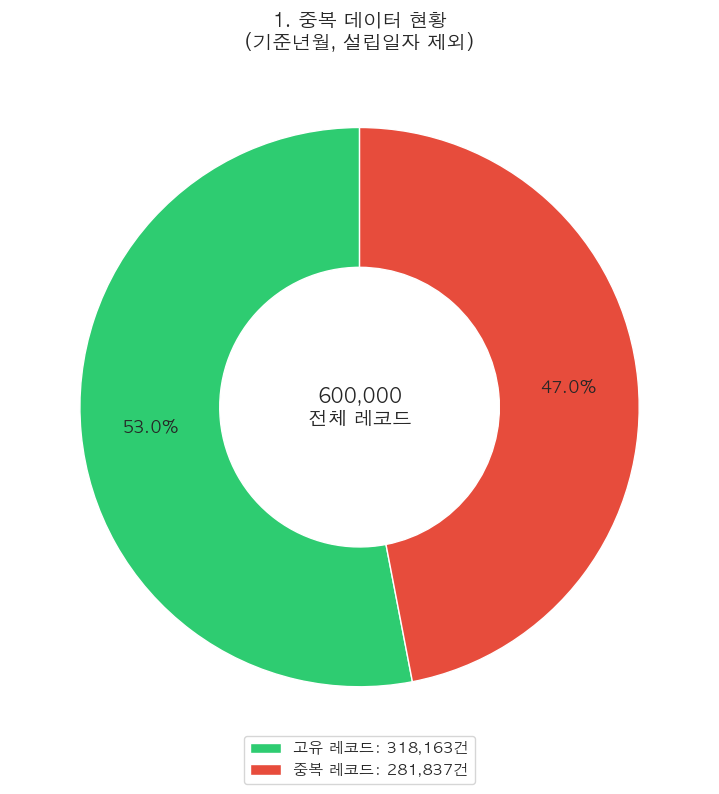

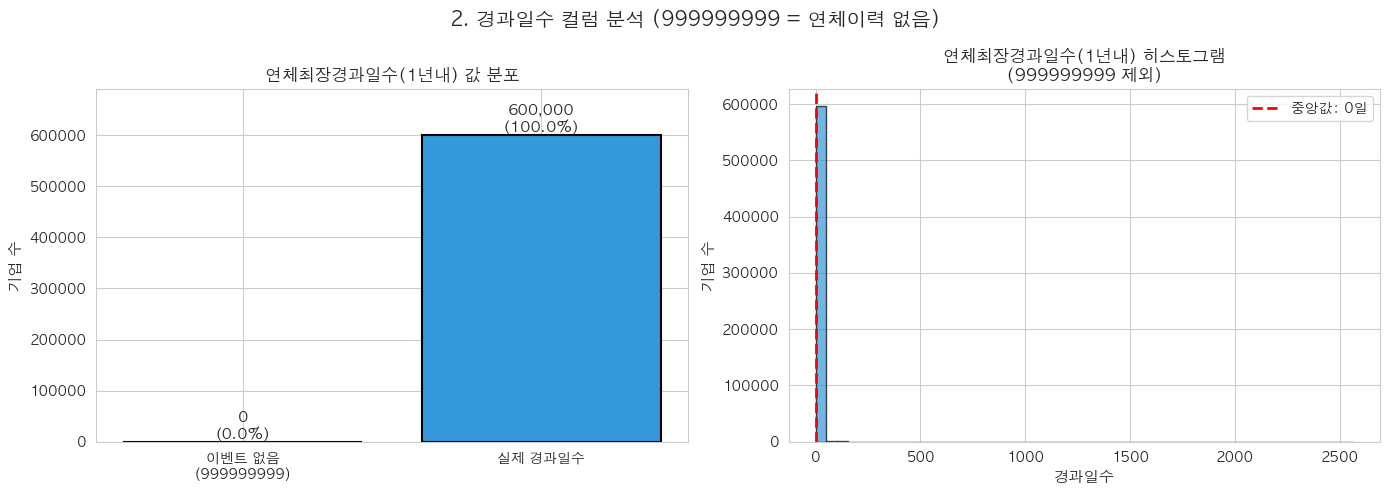

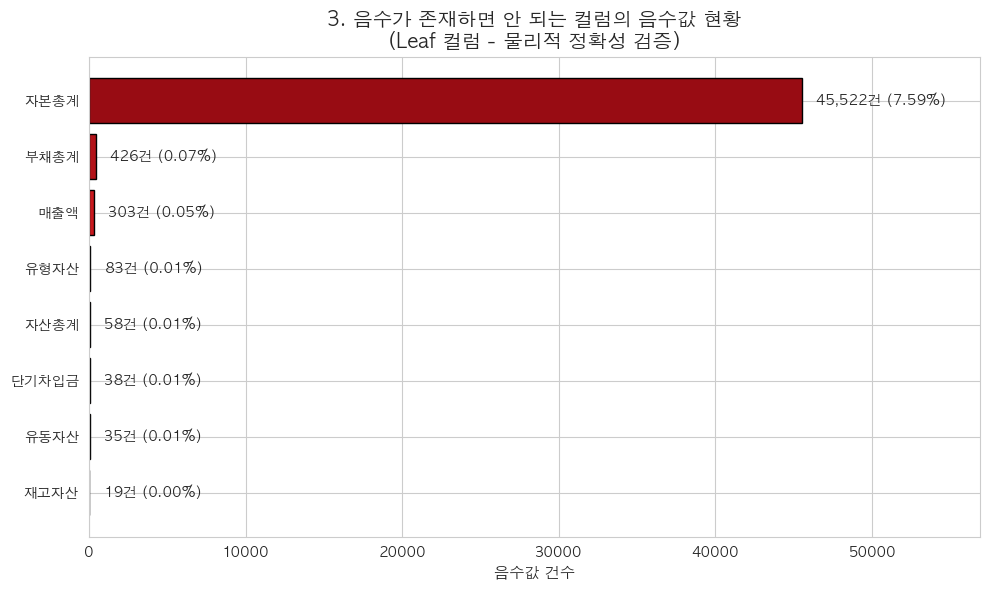

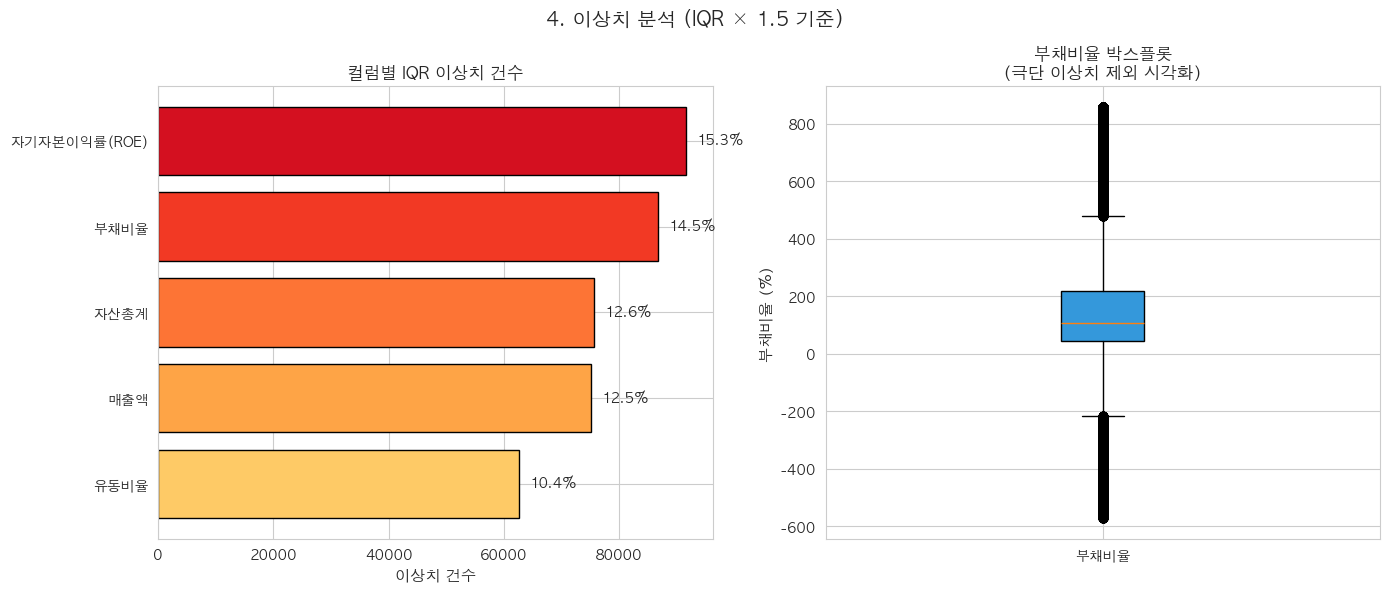

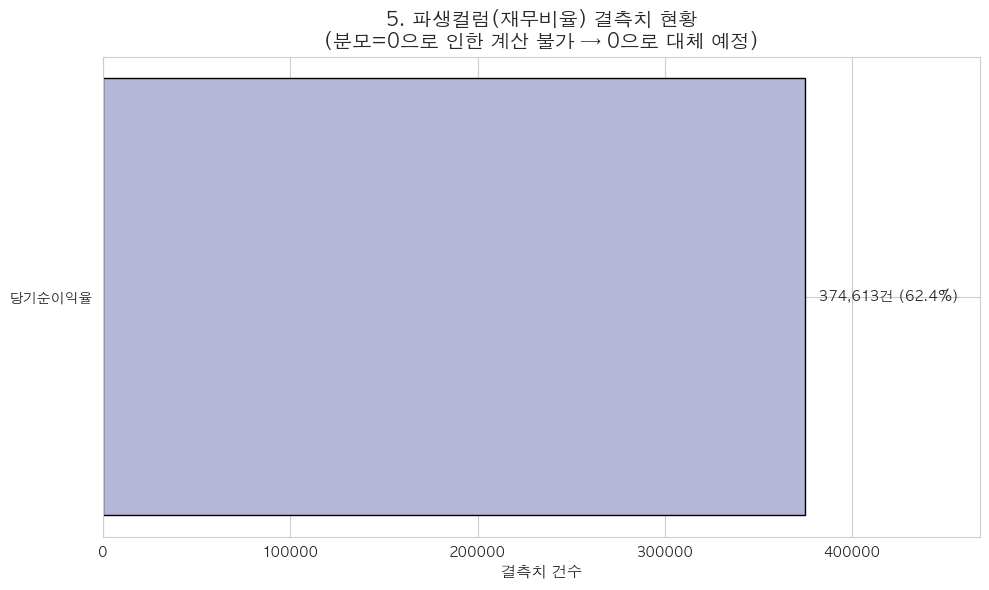


✅ 5개 시각화 완료!
  - eda_1_duplicates.png
  - eda_2_days_elapsed.png
  - eda_3_negative_values.png
  - eda_4_outliers.png
  - eda_5_missing_derived.png


In [24]:
# ============================================================
# EDA 데이터 품질 시각화 코드 (한글 컬럼명 버전)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('/Users/kje/coding/project/fintech-cb-pipeline/data/raw/기업신용평가정보_합성데이터.csv', encoding='cp949')
print(f"데이터 크기: {len(df):,}행, {len(df.columns)}열")

# ============================================================
# 1. 중복 데이터 확인 (기준년월, 설립일자 제외)
# ============================================================
exclude_cols = ['기준년월', '설립일자']
check_cols = [col for col in df.columns if col not in exclude_cols]

# 중복 확인
n_total = len(df)
n_duplicated_rows = df.duplicated(subset=check_cols, keep='first').sum()
n_unique = n_total - n_duplicated_rows

# 시각화: 도넛 차트
fig, ax = plt.subplots(figsize=(8, 8))
sizes = [n_unique, n_duplicated_rows]
colors = ['#2ecc71', '#e74c3c']
labels = [f'고유 레코드: {n_unique:,}건', f'중복 레코드: {n_duplicated_rows:,}건']

wedges, texts, autotexts = ax.pie(sizes, colors=colors, autopct='%1.1f%%',
                                    startangle=90, pctdistance=0.75,
                                    wedgeprops=dict(width=0.5, edgecolor='white'))
plt.setp(autotexts, size=12, weight='bold')
ax.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), fontsize=11)

centre_circle = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, f'{n_total:,}\n전체 레코드', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('1. 중복 데이터 현황\n(기준년월, 설립일자 제외)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_1_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 2. 경과일수 컬럼 분포 (999999999 = 이벤트 없음)
# ============================================================
col = '기업신용공여연체최장연체일수(일보)(1년내유지)(해제포함)'
col_short = '연체최장경과일수(1년내)'

special_value = 999999999
n_special = (df[col] == special_value).sum()
n_normal = (df[col] != special_value).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 특수값 vs 실제값 비율
ax1 = axes[0]
categories = ['이벤트 없음\n(999999999)', '실제 경과일수']
values = [n_special, n_normal]
colors = ['#f39c12', '#3498db']
bars = ax1.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('기업 수', fontsize=11)
ax1.set_title(f'{col_short} 값 분포', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(values) * 1.15)

# 오른쪽: 실제 경과일수 히스토그램 (999999999 제외)
ax2 = axes[1]
actual_days = df[df[col] != special_value][col]
if len(actual_days) > 0:
    ax2.hist(actual_days, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax2.axvline(actual_days.median(), color='red', linestyle='--', linewidth=2,
                label=f'중앙값: {actual_days.median():.0f}일')
    ax2.set_xlabel('경과일수', fontsize=11)
    ax2.set_ylabel('기업 수', fontsize=11)
    ax2.legend(fontsize=10)
ax2.set_title(f'{col_short} 히스토그램\n(999999999 제외)', fontsize=12, fontweight='bold')

plt.suptitle('2. 경과일수 컬럼 분석 (999999999 = 연체이력 없음)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_2_days_elapsed.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 3. 음수가 존재하면 안 되는 컬럼에 음수값 확인
# ============================================================
# 물리적으로 음수가 불가능한 컬럼들 (Leaf 컬럼: 자산, 부채, 매출 등)
non_negative_cols = [
    '자산총계',
    '부채총계',
    '자본총계',
    '매출액',
    '재고자산',
    '단기차입금',
    '유동자산',
    '유형자산'
]

# 존재하는 컬럼만 필터링
non_negative_cols = [col for col in non_negative_cols if col in df.columns]

# 음수 개수 집계
negative_data = []
for col in non_negative_cols:
    n_negative = (df[col] < 0).sum()
    if n_negative > 0:
        negative_data.append({'컬럼': col, '음수건수': n_negative, '비율': n_negative/len(df)*100})

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
if negative_data:
    neg_df = pd.DataFrame(negative_data).sort_values('음수건수', ascending=True)

    colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(neg_df)))
    bars = ax.barh(neg_df['컬럼'], neg_df['음수건수'], color=colors, edgecolor='black')

    for bar, (_, row) in zip(bars, neg_df.iterrows()):
        ax.text(bar.get_width() + max(neg_df['음수건수'])*0.02,
                bar.get_y() + bar.get_height()/2,
                f"{row['음수건수']:,}건 ({row['비율']:.2f}%)", va='center', fontsize=10)

    ax.set_xlabel('음수값 건수', fontsize=11)
    ax.set_title('3. 음수가 존재하면 안 되는 컬럼의 음수값 현황\n(Leaf 컬럼 - 물리적 정확성 검증)',
                fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(neg_df['음수건수']) * 1.25)
else:
    ax.text(0.5, 0.5, '음수값이 발견되지 않았습니다', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)
    ax.set_title('3. 음수값 확인 결과', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_3_negative_values.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 4. 이상치 분석 (IQR 방식)
# ============================================================
# 주요 Leaf 컬럼
outlier_cols = [
    '자산총계',
    '매출액',
    '재무비율_부채비율',
    '재무비율_자기자본이익률(ROE)',
    '재무비율_유동비율'
]
outlier_cols = [col for col in outlier_cols if col in df.columns]

# IQR 이상치 계산
outlier_data = []
for col in outlier_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    outlier_data.append({
        '컬럼': col.replace('재무비율_', ''),  # 이름 간략화
        '이상치수': n_outliers,
        '비율': n_outliers / len(data) * 100
    })

outlier_df = pd.DataFrame(outlier_data).sort_values('이상치수', ascending=True)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 이상치 건수 막대그래프
ax1 = axes[0]
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.8, len(outlier_df)))
bars = ax1.barh(outlier_df['컬럼'], outlier_df['이상치수'], color=colors, edgecolor='black')
for bar, (_, row) in zip(bars, outlier_df.iterrows()):
    ax1.text(bar.get_width() + max(outlier_df['이상치수'])*0.02,
            bar.get_y() + bar.get_height()/2,
            f"{row['비율']:.1f}%", va='center', fontsize=10)
ax1.set_xlabel('이상치 건수', fontsize=11)
ax1.set_title('컬럼별 IQR 이상치 건수', fontsize=12, fontweight='bold')

# 오른쪽: 부채비율 박스플롯
ax2 = axes[1]
sample_col = '재무비율_부채비율'
if sample_col in df.columns:
    data = df[sample_col].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    # 극단값 제외 (시각화 목적)
    plot_data = data[(data >= Q1 - 3*IQR) & (data <= Q3 + 3*IQR)]

    bp = ax2.boxplot(plot_data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    ax2.set_ylabel('부채비율 (%)', fontsize=11)
    ax2.set_xticklabels(['부채비율'])
    ax2.set_title('부채비율 박스플롯\n(극단 이상치 제외 시각화)', fontsize=12, fontweight='bold')

plt.suptitle('4. 이상치 분석 (IQR × 1.5 기준)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_4_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 5. 파생컬럼(재무비율) 결측치 현황
# ============================================================
# 파생 컬럼 (분모가 0일 때 계산 불가)
derived_cols = [
    '재무비율_부채비율',
    '재무비율_자기자본비율',
    '재무비율_유동비율',
    '재무비율_자기자본이익률(ROE)',
    '재무비율_영업이익율',
    '재무비율_당기순이익율',
    '순운전자본회전율',
    'EBITDA마진율'
]
derived_cols = [col for col in derived_cols if col in df.columns]

# 결측치 집계
missing_data = []
for col in derived_cols:
    n_missing = df[col].isna().sum()
    # NaN 또는 inf도 결측으로 처리
    n_inf = np.isinf(df[col].replace([np.inf, -np.inf], np.nan)).sum() if df[col].dtype in ['float64', 'int64'] else 0
    total_missing = n_missing + n_inf
    if total_missing > 0:
        missing_data.append({
            '컬럼': col.replace('재무비율_', ''),
            '결측건수': total_missing,
            '비율': total_missing / len(df) * 100
        })

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
if missing_data:
    miss_df = pd.DataFrame(missing_data).sort_values('결측건수', ascending=True)

    colors = plt.cm.Purples(np.linspace(0.4, 0.8, len(miss_df)))
    bars = ax.barh(miss_df['컬럼'], miss_df['결측건수'], color=colors, edgecolor='black')

    for bar, (_, row) in zip(bars, miss_df.iterrows()):
        ax.text(bar.get_width() + max(miss_df['결측건수'])*0.02,
                bar.get_y() + bar.get_height()/2,
                f"{row['결측건수']:,}건 ({row['비율']:.1f}%)", va='center', fontsize=10)

    ax.set_xlabel('결측치 건수', fontsize=11)
    ax.set_title('5. 파생컬럼(재무비율) 결측치 현황\n(분모=0으로 인한 계산 불가 → 0으로 대체 예정)',
                fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(miss_df['결측건수']) * 1.25)
else:
    ax.text(0.5, 0.5, '결측치가 발견되지 않았습니다', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)
    ax.set_title('5. 파생컬럼 결측치 확인 결과', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_5_missing_derived.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n✅ 5개 시각화 완료!")
print("  - eda_1_duplicates.png")
print("  - eda_2_days_elapsed.png")
print("  - eda_3_negative_values.png")
print("  - eda_4_outliers.png")
print("  - eda_5_missing_derived.png")